<a href="https://colab.research.google.com/github/MishterBluesky/CoEVFold/blob/main/CoEV_Mapper_with_STRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CoEV_Mapper (Bootstrapped!) 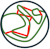

This notebook, derived from MMSEQ2 and GREMLIN finds co-evolutionary interactions based on the input sequence, creating a network of interactions. In order to work, it randomly removes amino acids from sequences, meaning what we see here is at the gene level, for specifics, the proteins must be put in other engines.

It will create a network and heatmap of which genes likely interact with each based on a normaised score to self.

Note: It is now promiscuity adjusted, leak adjusted and bootstrapped! it does the best it can with coevolution to make maps. There is nothing better.

Please note there is a minimum length set by the ambition parameter. The higher the ambition the more accurate but the more GPUs taken. This recommended 600 for normal inputs less than 4000 amino acids total, and higher if above, up to 2000 a.a is possible on a HD100 server. Higher bootstrapping also increases accuracy

In [ ]:
%%time
#@title setup
unified_memory = False #@param {type:"boolean"}
import os, time, gc
if unified_memory:
  ENV = {"TF_FORCE_UNIFIED_MEMORY":"1", "XLA_PYTHON_CLIENT_MEM_FRACTION":"4.0"}
  for k,v in ENV.items(): os.environ[k] = v
if not os.path.isdir("params"):
  # get code
  print("installing ColabDesign")

  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@gamma")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")
  os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/main/colabfold/colabfold.py -O colabfold_utils.py")
  #os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/beta/colabfold/mmseqs/api.py")

  # install hhsuite
  print("installing HHsuite")
  os.makedirs("hhsuite", exist_ok=True)
  os.system(f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C hhsuite/")

if "hhsuite" not in os.environ['PATH']:
  os.environ['PATH'] += ":hhsuite/bin:hhsuite/scripts"

import re, tempfile
from IPython.display import HTML
from google.colab import files
import numpy as np
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib import predict
from colabdesign.af.contrib.cyclic import add_cyclic_offset
from colabdesign.shared.protein import _np_rmsd, _np_kabsch
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap


import jax
import jax.numpy as jnp
from colabfold_utils import run_mmseqs2
import matplotlib.pyplot as plt
import string
import numpy as np

def clear_mem():
  backend = jax.lib.xla_bridge.get_backend()
  for buf in backend.live_buffers(): buf.delete()

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.cif -P tmp/")
    return f"tmp/{pdb_code}.cif"
  else:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v4.pdb -P tmp/")
    return f"tmp/AF-{pdb_code}-F1-model_v4.pdb"

def run_hhalign(query_sequence, target_sequence, query_a3m=None, target_a3m=None):
  with tempfile.NamedTemporaryFile() as tmp_query, \
  tempfile.NamedTemporaryFile() as tmp_target, \
  tempfile.NamedTemporaryFile() as tmp_alignment:
    if query_a3m is None:
      tmp_query.write(f">Q\n{query_sequence}\n".encode())
      tmp_query.flush()
      query_a3m = tmp_query.name
    if target_a3m is None:
      tmp_target.write(f">T\n{target_sequence}\n".encode())
      tmp_target.flush()
      target_a3m = tmp_target.name
    os.system(f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}")
    X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
  return X, start_indices

def run_do_not_align(query_sequence, target_sequence, **arg):
  return [query_sequence,target_sequence],[0,0]

def run_hhfilter(input, output, id=90, qid=10):
  os.system(f"hhfilter -id {id} -qid {qid} -i {input} -o {output}")

@jax.jit
def get_coevolution(X):
  '''given one-hot encoded MSA, return contacts'''
  Y = jax.nn.one_hot(X,22)
  N,L,A = Y.shape
  Y_flat = Y.reshape(N,-1)
  # covariance
  c = jnp.cov(Y_flat.T)

  # inverse covariance
  shrink = 4.5/jnp.sqrt(N) * jnp.eye(c.shape[0])
  ic = jnp.linalg.inv(c + shrink)

  # partial correlation coefficient
  ic_diag = jnp.diag(ic)
  pcc = ic / jnp.sqrt(ic_diag[:,None] * ic_diag[None,:])

  raw = jnp.sqrt(jnp.square(pcc.reshape(L,A,L,A)[:,:20,:,:20]).sum((1,3)))
  i = jnp.arange(L)
  raw = raw.at[i,i].set(0)
  # do apc
  ap = raw.sum(0,keepdims=True) * raw.sum(1,keepdims=True) / raw.sum()
  return (raw - ap).at[i,i].set(0)

def plot_3D(aux, Ls, file_name, show=False):
  plt.figure(figsize=(10,5))
  xyz = aux["atom_positions"][:,1]
  xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
  ax = plt.subplot(1,2,1)
  if len(Ls) > 1:
    plt.title("chain")
    c = np.concatenate([[n]*L for n,L in enumerate(Ls)])
    plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
  else:
    plt.title("length")
    plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
  plt.axis(False)
  ax = plt.subplot(1,2,2)
  plt.title("plddt")
  plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
  plt.axis(False)
  plt.savefig(file_name, dpi=200, bbox_inches='tight')
  plt.show() if show else plt.close()

installing ColabDesign
installing HHsuite
CPU times: user 4.16 ms, sys: 65 µs, total: 4.22 ms
Wall time: 10.1 s


<>:208: SyntaxWarning: invalid escape sequence '\('
<>:214: SyntaxWarning: invalid escape sequence '\)'
<>:208: SyntaxWarning: invalid escape sequence '\('
<>:214: SyntaxWarning: invalid escape sequence '\)'
/tmp/ipykernel_778/51769660.py:208: SyntaxWarning: invalid escape sequence '\('
  "\(",
/tmp/ipykernel_778/51769660.py:214: SyntaxWarning: invalid escape sequence '\)'
  "\)",


Saving COAT_string_protein_sequences_59_nodes.fa to COAT_string_protein_sequences_59_nodes.fa
Found 59 sequences:

FASTA input:
----------------------------------------------------------------------
  1  224308.BSU19780              133 aa
  2  224308.BSU19790              317 aa
  3  224308.BSU19770              101 aa
  4  224308.BSU06300              513 aa
  5  224308.BSU36050              380 aa
  6  224308.BSU17700               66 aa
  7  224308.BSU22200               75 aa
  8  224308.BSU17030              181 aa
  9  224308.BSU40530              160 aa
 10  224308.BSU36070              195 aa
 11  224308.BSU36060              362 aa
 12  224308.BSU30920              357 aa
 13  224308.BSU06890               82 aa
 14  224308.BSU06900               87 aa
 15  224308.BSU06910              189 aa
 16  224308.BSU17970              130 aa
 17  224308.BSU11730              227 aa
 18  224308.BSU05550              143 aa
 19  224308.BSU34530              320 aa
 20  224308.BSU30900  

COMPLETE: 100%|██████████| 8850/8850 [elapsed: 00:30 remaining: 00:00]


parsing msas
gathering info
filtering sequences
selecting final sequences


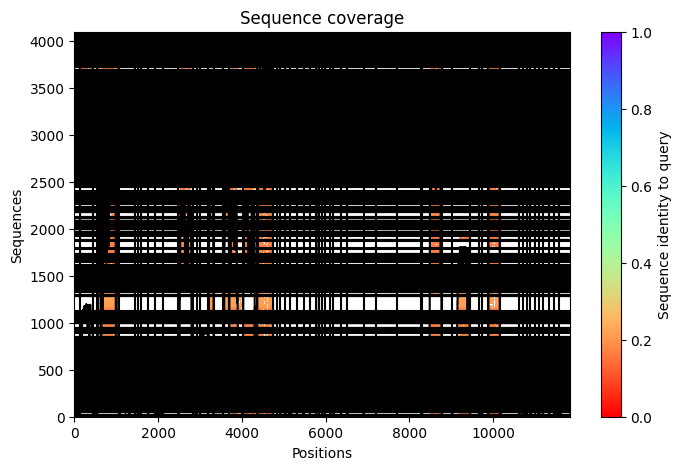


GC 99155

Finished preparing: 224308BSU19780224308BSU19790224308BSU19770224308BSU06300224308BSU36050and_54_more_87314

Input chains:
  1: 224308.BSU19780 (133 aa)
  2: 224308.BSU19790 (317 aa)
  3: 224308.BSU19770 (101 aa)
  4: 224308.BSU06300 (513 aa)
  5: 224308.BSU36050 (380 aa)
  6: 224308.BSU17700 (66 aa)
  7: 224308.BSU22200 (75 aa)
  8: 224308.BSU17030 (181 aa)
  9: 224308.BSU40530 (160 aa)
  10: 224308.BSU36070 (195 aa)
  11: 224308.BSU36060 (362 aa)
  12: 224308.BSU30920 (357 aa)
  13: 224308.BSU06890 (82 aa)
  14: 224308.BSU06900 (87 aa)
  15: 224308.BSU06910 (189 aa)
  16: 224308.BSU17970 (130 aa)
  17: 224308.BSU11730 (227 aa)
  18: 224308.BSU05550 (143 aa)
  19: 224308.BSU34530 (320 aa)
  20: 224308.BSU30900 (351 aa)
  21: 224308.BSU30910 (377 aa)
  22: 224308.BSU12090 (82 aa)
  23: 224308.BSU17670 (86 aa)
  24: 224308.BSU11780 (128 aa)
  25: 224308.BSU11770 (105 aa)
  26: 224308.BSU11760 (172 aa)
  27: 224308.BSU11750 (162 aa)
  28: 224308.BSU11740 (148 aa)
  29: 224308.

In [ ]:
#@title prep_inputs
#@markdown Upload a FASTA file. Each FASTA sequence becomes a separate chain, separated by ":".

from google.colab import files
from Bio import SeqIO
import re
import os
import gc

# ============================================================
# UPLOAD FASTA
# ============================================================

uploaded = files.upload()
fasta_file = list(uploaded.keys())[0]

records = list(SeqIO.parse(fasta_file, "fasta"))

if len(records) == 0:
    raise ValueError("No FASTA sequences found.")

print(f"Found {len(records)} sequences:\n")


# ============================================================
# SIMPLIFY FASTA HEADER
# ============================================================

def simplify_header(record):

    name = record.id

    # UniProt style:
    # sp|P12345|PROTEIN_NAME
    # tr|A0A123|PROTEIN_NAME
    if "|" in name:
        parts = name.split("|")

        if len(parts) >= 2:
            name = parts[1]

    # Remove version numbers:
    # WP_012345.1 -> WP_012345
    name = re.sub(r'\.\d+$', '', name)

    # Make safe for filenames/job names
    name = re.sub(r'[^A-Za-z0-9_.-]', '_', name)

    # Remove repeated separators
    name = re.sub(r'_+', '_', name)

    # Remove leading/trailing separators
    name = name.strip("._-")

    if not name:
        name = "sequence"

    return name


# ============================================================
# READ AND CLEAN ALL SEQUENCES
# ============================================================

sequences = []
names = []

for i, record in enumerate(records):

    seq = str(record.seq).upper()

    # Remove anything that isn't a protein character
    seq = re.sub("[^A-Z:/()]", "", seq)

    if len(seq) == 0:
        print(f"WARNING: {record.id} contains no valid sequence. Skipping.")
        continue

    sequences.append(seq)
    names.append(simplify_header(record))


# ============================================================
# SHOW INPUT
# ============================================================

print("FASTA input:")
print("-" * 70)

for i, (name, seq) in enumerate(zip(names, sequences)):

    print(
        f"{i+1:3d}  "
        f"{name:25s} "
        f"{len(seq):6d} aa"
    )

print("-" * 70)

print(
    f"Total chains: {len(sequences)}"
)

print(
    f"Total residues: {sum(len(x) for x in sequences)}"
)


# ============================================================
# JOIN SEQUENCES WITH ":"
# ============================================================

sequence = ":".join(sequences)

# This is now equivalent to:
#
# sequence = "SEQ1:SEQ2:SEQ3:SEQ4"
#
# from the original version.


# ============================================================
# JOB NAME
# ============================================================

# Use the simplified FASTA names to construct the job name.
#
# Example:
# WP_012345-WP_067890-P12345
#
# If there are many sequences, truncate the name to avoid
# excessively long directory names.

jobname = "-".join(names)

if len(jobname) > 150:
    jobname = "-".join(names[:5]) + f"-and_{len(names)-5}_more"

jobname = re.sub(
    r'[^A-Za-z0-9_.-]',
    '_',
    jobname
)

jobname_backup = jobname


# ============================================================
# COPIES
# ============================================================

copies = 1


#@markdown ----
#@markdown **MSA options**

msa_method = "mmseqs2" #@param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]

pair_mode = "paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}


#@markdown filtering options

cov = 50 #@param ["0", "25", "50", "75", "90", "99"] {type:"raw"}

id = 100 #@param ["90", "95", "100"] {type:"raw"}

qid = 0 #@param ["0", "10", "15", "20", "30"] {type:"raw"}

do_not_filter = False #@param {type:"boolean"}


# ============================================================
# TEMPLATE OPTIONS
# ============================================================

template_mode = "none"

use_templates = template_mode in [
    "mmseqs2",
    "custom"
]

pdb = ""
chain = "A"

rm_template_seq = False
propagate_to_copies = True
do_not_align = False

rm_sidechain = rm_sequence = rm_template_seq


# ============================================================
# CLEAN SEQUENCE
# ============================================================

sequence = sequence.upper()

sequence = re.sub(
    "[^A-Z:/()]",
    "",
    sequence.upper()
)

sequence = re.sub(
    "\(",
    ":(",
    sequence
)

sequence = re.sub(
    "\)",
    "):",
    sequence
)

sequence = re.sub(
    ":+",
    ":",
    sequence
)

sequence = re.sub(
    "/+",
    "/",
    sequence
)

sequence = re.sub(
    "^[:/]+",
    "",
    sequence
)

sequence = re.sub(
    "[:/]+$",
    "",
    sequence
)

jobname = re.sub(
    r'\W+',
    '',
    jobname
)


# ============================================================
# PROCESS SEQUENCE
# ============================================================

sequences = sequence.split(":")

u_sequences = predict.get_unique_sequences(
    sequences
)

u_cyclic = [
    x.startswith("(")
    for x in u_sequences
]

u_sub_lengths = [
    [len(y) for y in x.split("/")]
    for x in u_sequences
]

u_sequences = [
    x.replace("(", "")
     .replace(")", "")
     .replace("/", "")
    for x in u_sequences
]


if len(sequences) > len(u_sequences):

    print(
        "WARNING: duplicate sequences detected."
    )

    print(
        "Use copies to define homooligomers."
    )


u_lengths = [
    len(x)
    for x in u_sequences
]

sub_seq = "".join(u_sequences)

seq = sub_seq * copies


# ============================================================
# HASH
# ============================================================

jobname = f"{jobname}_{predict.get_hash(seq)[:5]}"


# ============================================================
# AVOID EXISTING JOB
# ============================================================

def check(folder):
    return os.path.exists(folder)


if check(jobname):

    n = 0

    while check(f"{jobname}_{n}"):
        n += 1

    jobname = f"{jobname}_{n}"


print("\n")
print("=" * 70)

print(
    "jobname:",
    jobname
)

print(
    f"chains={len(u_sequences)}"
)

print(
    f"length={u_lengths}"
)

print(
    f"copies={copies}"
)

print("=" * 70)


# ============================================================
# INPUT OPTIONS
# ============================================================

input_opts = {
    "sequence": u_sequences,
    "copies": copies,
    "msa_method": msa_method,
    "pair_mode": pair_mode,
    "do_not_filter": do_not_filter,
    "cov": cov,
    "id": id,
    "template_mode": template_mode,
    "propagate_to_copies": propagate_to_copies
}


# ============================================================
# MMSEQS2 WRAPPER
# ============================================================

def run_mmseqs2_wrapper(*args, **kwargs):

    kwargs['user_agent'] = "colabdesign/gamma"

    return run_mmseqs2(*args, **kwargs)


# ============================================================
# GET MSA
# ============================================================

os.makedirs(
    jobname,
    exist_ok=True
)

Ls = [
    len(x)
    for x in u_sequences
]


if msa_method == "mmseqs2":

    msa, deletion_matrix = predict.get_msa(
        u_sequences,
        jobname,
        mode=pair_mode,
        cov=cov,
        id=id,
        qid=qid,
        max_msa=4096,
        do_not_filter=do_not_filter,
        mmseqs2_fn=run_mmseqs2_wrapper,
        hhfilter_fn=run_hhfilter
    )


elif msa_method == "single_sequence":

    with open(
        f"{jobname}/msa.a3m",
        "w"
    ) as a3m:

        a3m.write(
            f">{jobname}\n{sub_seq}\n"
        )

    msa, deletion_matrix = predict.parse_a3m(
        f"{jobname}/msa.a3m"
    )


else:

    msa_format = msa_method.split("_")[1]

    print(
        f"upload {msa_method}"
    )

    msa_dict = files.upload()

    lines = []

    for k, v in msa_dict.items():

        lines += v.decode().splitlines()

    input_lines = []

    for line in lines:

        line = line.replace(
            "\x00",
            ""
        )

        if (
            len(line) > 0
            and not line.startswith('#')
        ):

            input_lines.append(line)


    with open(
        f"{jobname}/msa.{msa_format}",
        "w"
    ) as msa:

        msa.write(
            "\n".join(input_lines)
        )


    if msa_format != "a3m":

        os.system(
            f"perl hhsuite/scripts/reformat.pl "
            f"{msa_format} a3m "
            f"{jobname}/msa.{msa_format} "
            f"{jobname}/msa.a3m"
        )


    if do_not_filter:

        os.system(
            f"hhfilter "
            f"-qid 0 "
            f"-id 100 "
            f"-cov 0 "
            f"-i {jobname}/msa.a3m "
            f"-o {jobname}/msa.filt.a3m"
        )

    else:

        os.system(
            f"hhfilter "
            f"-qid {qid} "
            f"-id {id} "
            f"-cov {cov} "
            f"-i {jobname}/msa.a3m "
            f"-o {jobname}/msa.filt.a3m"
        )


    msa, deletion_matrix = predict.parse_a3m(
        f"{jobname}/msa.filt.a3m"
    )


# ============================================================
# PLOT MSA
# ============================================================

if len(msa) > 1:

    predict.plot_msa(
        msa,
        Ls
    )

    plt.savefig(
        f"{jobname}/msa_feats.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# TEMPLATES
# ============================================================

if use_templates:

    print("aligning template")

    template_msa = (
        f"{jobname}/msa.a3m"
    )


    if template_mode == "mmseqs2":

        predict.get_msa(
            u_sequences,
            jobname,
            mode="unpaired",
            mmseqs2_fn=run_mmseqs2_wrapper,
            do_not_filter=True,
            do_not_return=True,
            output_a3m=f"{jobname}/msa_tmp.a3m"
        )

        template_msa = (
            f"{jobname}/msa_tmp.a3m"
        )


        if (
            not propagate_to_copies
            and copies > 1
        ):

            new_msa = []

            with open(
                template_msa,
                "r"
            ) as handle:

                for line in handle:

                    if not line.startswith(">"):

                        new_msa.append(
                            line.rstrip()
                        )


            with open(
                template_msa,
                "w"
            ) as handle:

                for n, seq in enumerate(new_msa):

                    handle.write(
                        f">{n}\n{seq * copies}\n"
                    )


        templates = {}

        print(
            "ID\tpdb\tcid\tevalue"
        )


        for line in open(
            f"{jobname}/msa/_env/pdb70.m8",
            "r"
        ):

            p = line.rstrip().split()

            M, target_id, qid, e_value = (
                p[0],
                p[1],
                p[2],
                p[10]
            )

            M = int(M)


            if M not in templates:

                templates[M] = []


            if len(templates[M]) < 4:

                print(
                    f"{int(M)}\t"
                    f"{target_id}\t"
                    f"{qid}\t"
                    f"{e_value}"
                )

                templates[M].append(
                    target_id
                )


        if len(templates) == 0:

            use_templates = False

            print(
                "ERROR: no templates found..."
            )


        else:

            Ms = sorted(
                list(templates.keys())
            )

            pdbs, chains = [], []


            for M in Ms:

                for n, target_id in enumerate(
                    templates[M]
                ):

                    pdb_id, chain_id = (
                        target_id.split("_")
                    )


                    if len(pdbs) < n + 1:

                        pdbs.append([])
                        chains.append([])


                    pdbs[n].append(
                        pdb_id
                    )

                    chains[n].append(
                        chain_id
                    )


            print(pdbs)


    else:

        pdbs, chains = [pdb], [chain]


# ============================================================
# TEMPLATE FEATURES
# ============================================================

if use_templates:

    input_opts.update({
        "pdbs": pdbs,
        "chains": chains
    })

    batches = []


    for pdb, chain in zip(
        pdbs,
        chains
    ):

        query_seq = "".join(
            u_sequences
        )


        batch = predict.get_template_feats(
            pdb,
            chain,
            query_seq=query_seq,
            query_a3m=template_msa,
            copies=copies,
            propagate_to_copies=propagate_to_copies,
            use_seq=not rm_sequence,
            get_pdb_fn=get_pdb,
            align_fn=(
                run_do_not_align
                if do_not_align
                else run_hhalign
            )
        )


        batches.append(batch)


    # --------------------------------------------------------
    # DISPLAY TEMPLATE FEATURES
    # --------------------------------------------------------

    plt.figure(
        figsize=(3 * len(batches), 3)
    )


    for n, batch in enumerate(
        batches
    ):

        plt.subplot(
            1,
            len(batches),
            n + 1
        )

        plt.title(
            f"template features {n + 1}"
        )


        dgram = (
            batch["dgram"]
            .argmax(-1)
            .astype(float)
        )


        dgram[
            batch["dgram"].sum(-1) == 0
        ] = np.nan


        Ln = dgram.shape[0]


        plt.imshow(
            dgram,
            extent=(0, Ln, Ln, 0)
        )


        predict.plot_ticks(
            Ls * copies
        )


    plt.savefig(
        f"{jobname}/template_feats.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


else:

    batches = [None]


# ============================================================
# FINISH
# ============================================================

print(
    "\nGC",
    gc.collect()
)

print(
    "\nFinished preparing:",
    jobname
)

print(
    "\nInput chains:"
)

for i, (name, seq) in enumerate(
    zip(names, sequences)
):

    print(
        f"  {i+1}: {name} ({len(seq)} aa)"
    )

print(
    "\nSequences were combined as:"
)

print(
    ":".join(names)
)

In [ ]:
#@title Sequence separation and counting

# ============================================================
# SPLIT THE MULTIMER SEQUENCE INTO INDIVIDUAL CHAINS
# ============================================================

sequence_segments = sequence.split(":")


# ============================================================
# USE THE FASTA NAMES DIRECTLY
# ============================================================

job_names = names


# ============================================================
# CHECK THAT EVERYTHING MATCHES
# ============================================================

if len(sequence_segments) != len(job_names):

    print(
        "Warning: the number of FASTA names and "
        "sequence segments do not match."
    )

    print(
        f"Number of names: {len(job_names)}"
    )

    print(
        f"Number of sequence segments: "
        f"{len(sequence_segments)}"
    )


# ============================================================
# CALCULATE SEQUENCE LENGTHS
# ============================================================

sequence_lengths = [
    len(segment.replace(" ", ""))
    for segment in sequence_segments
]


# ============================================================
# PAIR FASTA NAME + SEQUENCE LENGTH
# ============================================================

length_name_pairs = list(
    zip(
        job_names,
        sequence_lengths
    )
)


# ============================================================
# OUTPUT
# ============================================================

print("=" * 60)
print("Sequence information")
print("=" * 60)

for i, (name, length) in enumerate(
    length_name_pairs
):

    print(
        f"{i+1:3d}  "
        f"{name:30s} "
        f"{length:6d} aa"
    )

print("=" * 60)


# ============================================================
# REPORT ANY MISMATCH
# ============================================================

if len(sequence_segments) > len(job_names):

    print(
        "\nAdditional sequence segments without names:"
    )

    for segment in sequence_segments[len(job_names):]:

        print(
            f"  {len(segment)} aa"
        )


elif len(job_names) > len(sequence_segments):

    print(
        "\nAdditional names without sequence segments:"
    )

    for name in job_names[len(sequence_segments):]:

        print(
            f"  {name}"
        )

Sequence information
  1  224308.BSU19780                   133 aa
  2  224308.BSU19790                   317 aa
  3  224308.BSU19770                   101 aa
  4  224308.BSU06300                   513 aa
  5  224308.BSU36050                   380 aa
  6  224308.BSU17700                    66 aa
  7  224308.BSU22200                    75 aa
  8  224308.BSU17030                   181 aa
  9  224308.BSU40530                   160 aa
 10  224308.BSU36070                   195 aa
 11  224308.BSU36060                   362 aa
 12  224308.BSU30920                   357 aa
 13  224308.BSU06890                    82 aa
 14  224308.BSU06900                    87 aa
 15  224308.BSU06910                   189 aa
 16  224308.BSU17970                   130 aa
 17  224308.BSU11730                   227 aa
 18  224308.BSU05550                   143 aa
 19  224308.BSU34530                   320 aa
 20  224308.BSU30900                   351 aa
 21  224308.BSU30910                   377 aa
 22  224308.B

In [ ]:
#@title Sequence boundaries

# ============================================================
# SEPARATE THE MULTIMER INTO INDIVIDUAL CHAINS
# ============================================================

sequence_segments = sequence.split(":")

# IMPORTANT:
# Use the original FASTA names directly.
# Do NOT use jobname_backup.split("-")
job_names = names


# ============================================================
# CHECK
# ============================================================

if len(sequence_segments) != len(job_names):

    print("WARNING: sequence/name mismatch")

    print(
        f"Sequences: {len(sequence_segments)}"
    )

    print(
        f"Names:     {len(job_names)}"
    )


# ============================================================
# CALCULATE BOUNDARIES
# ============================================================

segment_boundaries = []

current_start = 0

for segment, name in zip(
    sequence_segments,
    job_names
):

    # Remove spaces
    segment_length = len(
        segment.replace(" ", "")
    )

    current_end = (
        current_start +
        segment_length
    )

    segment_boundaries.append(
        (
            name,
            current_start,
            current_end
        )
    )

    current_start = current_end


# ============================================================
# OUTPUT
# ============================================================

print("=" * 70)
print("Sequence boundaries")
print("=" * 70)

for name, start, end in segment_boundaries:

    print(
        f"Job Name: {name:25s} "
        f"Start: {start:6d} "
        f"End: {end:6d}"
    )

print("=" * 70)

print(
    f"Total sequences: {len(segment_boundaries)}"
)

print(
    f"Total residues: {current_start}"
)

Sequence boundaries
Job Name: 224308.BSU19780           Start:      0 End:    133
Job Name: 224308.BSU19790           Start:    133 End:    450
Job Name: 224308.BSU19770           Start:    450 End:    551
Job Name: 224308.BSU06300           Start:    551 End:   1064
Job Name: 224308.BSU36050           Start:   1064 End:   1444
Job Name: 224308.BSU17700           Start:   1444 End:   1510
Job Name: 224308.BSU22200           Start:   1510 End:   1585
Job Name: 224308.BSU17030           Start:   1585 End:   1766
Job Name: 224308.BSU40530           Start:   1766 End:   1926
Job Name: 224308.BSU36070           Start:   1926 End:   2121
Job Name: 224308.BSU36060           Start:   2121 End:   2483
Job Name: 224308.BSU30920           Start:   2483 End:   2840
Job Name: 224308.BSU06890           Start:   2840 End:   2922
Job Name: 224308.BSU06900           Start:   2922 End:   3009
Job Name: 224308.BSU06910           Start:   3009 End:   3198
Job Name: 224308.BSU17970           Start:   3198 

In [ ]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

#@title MMSEQ2 cleaning

def clean_and_adjust_sequences(sequences):
    """
    Cleans each sequence by removing newlines, spaces, and lowercase letters.
    Then, trims all sequences to ensure they are the same length,
    matching the shortest sequence.
    """

    # Step 1: Clean each sequence
    cleaned_sequences = [
        SeqRecord(
            Seq("".join([
                char for char in str(record.seq)
                if char.isupper() or char == '-'
            ])),
            id=record.id,
            description=""
        )
        for record in sequences
    ]

    # Step 2: Find the minimum length
    min_length = min(len(record.seq) for record in cleaned_sequences)

    print(f"Minimum cleaned sequence length: {min_length}")

    # Step 3: Trim all sequences to the minimum length
    adjusted_sequences = [
        SeqRecord(
            Seq(str(record.seq)[:min_length]),
            id=record.id,
            description=""
        )
        for record in cleaned_sequences
    ]

    return adjusted_sequences


# Load the MSA generated for the complete multimer
input_file = f"/content/{jobname}/msa.a3m"

msa_sequences = list(SeqIO.parse(input_file, "fasta"))

print(f"Loaded {len(msa_sequences)} MSA sequences")


# Clean and adjust the sequences
uniform_cleaned_sequences = clean_and_adjust_sequences(msa_sequences)


# Save back to the same .a3m file
output_file = f"/content/{jobname}/msa.a3m"

with open(output_file, "w") as output_handle:
    SeqIO.write(
        uniform_cleaned_sequences,
        output_handle,
        "fasta"
    )

print(f"Saved cleaned MSA to: {output_file}")

Loaded 4096 MSA sequences
Minimum cleaned sequence length: 11849
Saved cleaned MSA to: /content/224308BSU19780224308BSU19790224308BSU19770224308BSU06300224308BSU36050and_54_more_87314/msa.a3m


In [ ]:
import numpy as np
import random
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
ambition = 2000 #@param
# ==========================================================
# 1. Trim alignment to target length
# ==========================================================
def reduce_alignment_to_target_length(sequences, min_target_length=2000, max_target_length=2000):
    # Remove lowercase letters and build alignment matrix
    alignment_matrix = np.array([
        [char for char in str(record.seq) if char.isupper() or char == '-']
        for record in sequences
    ], dtype=str)

    alignment_length = alignment_matrix.shape[1]
    print(f"Original alignment length (after removing lowercase): {alignment_length}")

    min_length_after_removal = min(
        len(str(record.seq).replace(' ', '').upper())
        for record in sequences
    )

    target_length = min(
        max(min_length_after_removal, min_target_length),
        max_target_length
    )

    if alignment_length > target_length:
        columns_to_remove = alignment_length - target_length
        removed_columns = sorted(
            random.sample(range(alignment_length), columns_to_remove)
        )
        print(f"Removed columns: {removed_columns}")
    else:
        removed_columns = []

    trimmed_sequences = trim_sequences_to_remove_columns(
        sequences,
        removed_columns
    )

    return trimmed_sequences, removed_columns, target_length


def trim_sequences_to_remove_columns(sequences, removed_columns):
    trimmed_sequences = []
    removed_columns_set = set(removed_columns)

    for record in sequences:
        sequence = str(record.seq)

        trimmed_sequence = "".join([
            sequence[i]
            for i in range(len(sequence))
            if i not in removed_columns_set
        ])

        trimmed_sequences.append(
            SeqRecord(
                Seq(trimmed_sequence),
                id=record.id,
                description=""
            )
        )

    return trimmed_sequences


def process_msa_file(
    input_file,
    segment_boundaries,
    min_target_length=ambition,
    max_target_length=ambition,
):

    # Read the cleaned multimeric MSA
    msa_sequences = list(SeqIO.parse(input_file, "fasta"))

    trimmed_sequences, removed_columns, target_length = \
        reduce_alignment_to_target_length(
            msa_sequences,
            min_target_length,
            max_target_length
        )

    # Adjust the original FASTA chain boundaries
    new_segment_boundaries = []

    for name, original_start, original_end in segment_boundaries:

        new_start = original_start
        new_end = original_end

        num_removed_before_start = sum(
            1 for col in removed_columns
            if col < original_start
        )

        new_start -= num_removed_before_start

        num_removed_between_start_end = sum(
            1 for col in removed_columns
            if original_start <= col < original_end
        )

        new_end -= (
            num_removed_before_start +
            num_removed_between_start_end
        )

        new_segment_boundaries.append(
            (name, new_start, new_end)
        )

        print(
            f"Job Name: {name}, "
            f"New Start: {new_start}, "
            f"New End: {new_end}"
        )

    return (
        trimmed_sequences,
        removed_columns,
        new_segment_boundaries,
        target_length
    )


# ==========================================================
# 2. GREMLIN helpers
# ==========================================================
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

import matplotlib.pylab as plt
from scipy.spatial.distance import pdist, squareform
import pandas as pd

alphabet = "ARNDCQEGHILKMFPSTWYV-"
states = len(alphabet)
a2n = dict((a, n) for n, a in enumerate(alphabet))
aa2int = lambda x: a2n.get(x, a2n['-'])


def parse_a3m(filename):
    names, seqs, current_seq = [], [], ""

    with open(filename, "r") as file:
        for line in file:
            line = line.rstrip()

            if line.startswith(">"):
                if current_seq:
                    current_seq = ''.join([
                        c if c.isupper() or c == '-' else ''
                        for c in current_seq
                    ])

                    if current_seq.strip():
                        seqs.append(current_seq)

                current_seq = ""
                names.append(line[1:])

            else:
                current_seq += line

        if current_seq:
            current_seq = ''.join([
                c if c.isupper() or c == '-' else ''
                for c in current_seq
            ])

            if current_seq.strip():
                seqs.append(current_seq)

    return names, seqs


def filt_gaps(msa, gap_cutoff=1.0):
    frac_gaps = np.mean(
        (msa == states-1).astype(float),
        0
    )

    non_gaps = np.where(frac_gaps < gap_cutoff)[0]

    return msa[:, non_gaps], non_gaps


def get_eff(msa, eff_cutoff=0.8):
    msa_sm = 1.0 - squareform(
        pdist(msa, "hamming")
    )

    msa_w = (
        msa_sm >= eff_cutoff
    ).astype(float)

    msa_w = 1.0 / np.sum(msa_w, -1)

    return msa_w


def str2int(x):
    if x.dtype.type is np.str_:
        if x.ndim == 0:
            return np.array([
                aa2int(aa) for aa in x
            ])
        else:
            return np.array([
                [aa2int(aa) for aa in seq]
                for seq in x
            ])
    else:
        return x


def split_train_test(seqs, frac_test=0.1):
    x = np.copy(seqs)
    np.random.shuffle(x[1:])

    split = int(
        len(x) * (1.0-frac_test)
    )

    return x[:split], x[split:]


def mk_msa(seqs, gap_cutoff=1.0, eff_cutoff=0.8):
    msa_ori = str2int(seqs)

    msa, v_idx = filt_gaps(msa_ori)

    msa_weights = get_eff(
        msa,
        eff_cutoff
    )

    return {
        "msa_ori": msa_ori,
        "msa": msa,
        "weights": msa_weights,
        "neff": np.sum(msa_weights),
        "v_idx": v_idx,
        "nrow": msa.shape[0],
        "ncol": msa.shape[1],
        "ncol_ori": msa_ori.shape[1]
    }


def opt_adam(
    loss,
    name,
    var_list=None,
    lr=1.0,
    b1=0.9,
    b2=0.999,
    b_fix=False
):

    if var_list is None:
        var_list = tf.trainable_variables()

    gradients = tf.gradients(
        loss,
        var_list
    )

    opt = []

    for n, (x, g) in enumerate(
        zip(var_list, gradients)
    ):

        if g is not None:

            mt = tf.get_variable(
                name+"_mt_"+str(n),
                shape=list(x.shape),
                initializer=tf.zeros_initializer,
                trainable=False
            )

            vt = tf.get_variable(
                name+"_vt_"+str(n),
                shape=[],
                initializer=tf.zeros_initializer,
                trainable=False
            )

            mt_tmp = b1*mt+(1-b1)*g

            vt_tmp = (
                b2*vt +
                (1-b2)*tf.reduce_sum(tf.square(g))
            )

            lr_tmp = lr / (
                tf.sqrt(vt_tmp) + 1e-8
            )

            opt.append(
                x.assign_add(-lr_tmp * mt_tmp)
            )

            opt.append(
                vt.assign(vt_tmp)
            )

            opt.append(
                mt.assign(mt_tmp)
            )

    return tf.group(opt)


from collections import defaultdict


def GREMLIN(
    msa,
    opt_iter=200,
    opt_rate=1.0,
    batch_size=100,
    lam_v=0.01,
    lam_w=0.01,
    scale_lam_w=True,
    v=None,
    w=None,
    ignore_gap=False
):

    tf.reset_default_graph()

    ncol = msa["ncol"]

    MSA = tf.placeholder(
        tf.int32,
        shape=(None, ncol),
        name="msa"
    )

    MSA_weights = tf.placeholder(
        tf.float32,
        shape=(None,),
        name="msa_weights"
    )

    OH_MSA = tf.one_hot(
        MSA,
        states
    )

    if ignore_gap:
        ncat = states-1
        NO_GAP = 1.0 - OH_MSA[..., -1]
        OH_MSA = OH_MSA[..., :ncat]
    else:
        ncat = states

    V = tf.get_variable(
        name="V",
        shape=[ncol, ncat],
        initializer=tf.zeros_initializer
    )

    W_tmp = tf.get_variable(
        name="W",
        shape=[ncol, ncat, ncol, ncat],
        initializer=tf.zeros_initializer
    )

    W = W_tmp + tf.transpose(
        W_tmp,
        [2, 3, 0, 1]
    )

    W = W * (
        1-np.eye(ncol)
    )[:, None, :, None]

    VW = V + tf.tensordot(
        OH_MSA,
        W,
        2
    )

    H = tf.reduce_sum(
        OH_MSA*VW,
        -1
    )

    Z = tf.reduce_logsumexp(
        VW,
        -1
    )

    PLL = H - Z

    if ignore_gap:
        PLL = PLL * NO_GAP

    PLL = tf.reduce_sum(
        PLL,
        -1
    )

    PLL = tf.reduce_sum(
        MSA_weights*PLL
    ) / tf.reduce_sum(MSA_weights)

    L2_V = lam_v * tf.reduce_sum(
        tf.square(V)
    )

    L2_W = lam_w * tf.reduce_sum(
        tf.square(W)
    ) * 0.5

    if scale_lam_w:
        L2_W = L2_W * (
            ncol-1
        ) * (
            states-1
        )

    loss = -PLL + (
        L2_V + L2_W
    ) / msa["neff"]

    opt = opt_adam(
        loss,
        "adam",
        lr=opt_rate
    )

    all_idx = np.arange(
        msa["nrow"]
    )

    def feed(feed_all=False):

        if batch_size is None or feed_all:
            return {
                MSA: msa["msa"],
                MSA_weights: msa["weights"]
            }

        else:
            batch_idx = np.random.choice(
                all_idx,
                size=batch_size
            )

            return {
                MSA: msa["msa"][batch_idx],
                MSA_weights: msa["weights"][batch_idx]
            }

    with tf.Session() as sess:

        sess.run(
            tf.global_variables_initializer()
        )

        if v is None:

            oh_msa = np.eye(states)[
                msa["msa"]
            ]

            if ignore_gap:
                oh_msa = oh_msa[..., :-1]

            pseudo_count = (
                0.01 *
                np.log(msa["neff"])
            )

            f_v = np.einsum(
                "nla,n->la",
                oh_msa,
                msa["weights"]
            )

            V_ini = np.log(
                f_v + pseudo_count
            )

            if lam_v > 0:
                V_ini = (
                    V_ini -
                    np.mean(
                        V_ini,
                        axis=-1,
                        keepdims=True
                    )
                )

            sess.run(
                V.assign(V_ini)
            )

        else:
            sess.run(
                V.assign(v)
            )

        if w is not None:
            sess.run(
                W_tmp.assign(w*0.5)
            )

        get_loss = lambda: np.round(
            sess.run(
                loss,
                feed(True)
            ) * msa["neff"],
            2
        )

        print(
            "starting",
            get_loss()
        )

        for i in range(opt_iter):

            sess.run(
                opt,
                feed()
            )

            if (i+1) % int(opt_iter/10) == 0:
                print(
                    "iter",
                    (i+1),
                    get_loss()
                )

        V_ = sess.run(V)
        W_ = sess.run(W)

    no_gap_states = states - 1

    return {
        "v": V_[:, :no_gap_states],
        "w": W_[:, :no_gap_states, :, :no_gap_states],
        "v_idx": msa["v_idx"],
        "len": msa["ncol_ori"]
    }


# ==========================================================
# 3. BOOTSTRAP LOOP
# ==========================================================

n_bootstrap = 5 #@param

all_mrfs = []
all_boundaries = []
all_removed_columns = []

for i in range(n_bootstrap):

    print(
        f"\n=== Bootstrap iteration {i+1}/{n_bootstrap} ==="
    )

    trimmed_sequences, removed_columns, new_segment_boundaries, target_length = \
        process_msa_file(
            f"/content/{jobname}/msa.a3m",
            segment_boundaries
        )

    output_file = (
        f"/content/{jobname}/trimmed_alignment_{i}.a3m"
    )

    with open(
        output_file,
        "w"
    ) as output_handle:

        SeqIO.write(
            trimmed_sequences,
            output_handle,
            "fasta"
        )

    headers, seqs = parse_a3m(
        output_file
    )

    all_removed_columns.append(
        removed_columns
    )

    train_seqs, test_seqs = split_train_test(
        np.array(seqs, dtype=object),
        frac_test=0.1
    )

    np.random.shuffle(
        train_seqs
    )

    msa = mk_msa(
        np.array([
            list(seq)
            for seq in train_seqs
        ]),
        gap_cutoff=1.0,
        eff_cutoff=0.8
    )

    mrf = GREMLIN(
        msa,
        lam_w=0.01
    )

    all_mrfs.append(
        mrf
    )

    all_boundaries.append(
        new_segment_boundaries
    )


# ==========================================================
# 4. AVERAGE BOOTSTRAPPED MRFS
# ==========================================================

def average_mrfs_using_original_positions(
    all_mrfs,
    all_boundaries,
    all_removed_columns,
    original_segment_boundaries,
    total_target=ambition
):
    """
    Average multiple MRFs using original MSA positions to correctly
    assign residues to proteins.
    Uses original removed-column mappings to backmap each amino acid
    to its true column.
    """

    ncols = total_target
    nstates = all_mrfs[0]["v"].shape[1]

    # Use the true original total sequence length for scaling
    original_total = original_segment_boundaries[-1][2]

    compressed_total = total_target

    scale_factor = (
        compressed_total /
        original_total
    )

    final_boundaries = []

    for name, s, e in original_segment_boundaries:

        new_s = int(
            round(s * scale_factor)
        )

        new_e = int(
            round(e * scale_factor)
        )

        final_boundaries.append(
            (name, new_s, new_e)
        )

    # Adjust last boundary to exactly match total_target
    if final_boundaries[-1][2] != total_target:

        name, s, _ = final_boundaries[-1]

        final_boundaries[-1] = (
            name,
            s,
            total_target
        )

    print(
        f"Scaled final boundaries by {scale_factor:.3f}"
    )

    # ==========================================================
    # Initialize accumulators
    # ==========================================================

    v_accum = np.zeros(
        (ncols, nstates)
    )

    v_counts = np.zeros(
        ncols
    )

    w_accum = np.zeros(
        (ncols, nstates, ncols, nstates)
    )

    w_counts = np.zeros(
        (ncols, ncols)
    )

    # ==========================================================
    # Iterate over each bootstrap
    # ==========================================================

    for mrf, bounds, removed_columns in zip(
        all_mrfs,
        all_boundaries,
        all_removed_columns
    ):

        trimmed_len = mrf["len"]

        v_idx_trimmed = mrf["v_idx"]

        v = mrf["v"]
        w = mrf["w"]

        total_original_len = (
            trimmed_len +
            len(removed_columns)
        )

        original_positions = np.array([
            i
            for i in range(total_original_len)
            if i not in removed_columns
        ])

        if np.max(v_idx_trimmed) >= len(original_positions):

            print(
                f"Skipping out-of-range indices in MRF "
                f"(max v_idx={np.max(v_idx_trimmed)}, "
                f"len(original_positions)="
                f"{len(original_positions)})"
            )

            v_idx_trimmed = v_idx_trimmed[
                v_idx_trimmed < len(original_positions)
            ]

        v_idx_original = original_positions[
            v_idx_trimmed
        ]

        # ======================================================
        # improved residue-to-bin mapping
        # ======================================================

        for li, orig_pos in enumerate(
            v_idx_original
        ):

            pos = (
                orig_pos *
                scale_factor
            )

            low = int(
                np.floor(pos)
            )

            high = int(
                np.ceil(pos)
            )

            weight_high = pos - low
            weight_low = 1 - weight_high

            low = np.clip(
                low,
                0,
                ncols - 1
            )

            high = np.clip(
                high,
                0,
                ncols - 1
            )

            # Accumulate v
            v_accum[low] += (
                v[li] *
                weight_low
            )

            v_counts[low] += (
                weight_low
            )

            v_accum[high] += (
                v[li] *
                weight_high
            )

            v_counts[high] += (
                weight_high
            )

            # Accumulate w
            for lj, orig_pos2 in enumerate(
                v_idx_original
            ):

                pos2 = (
                    orig_pos2 *
                    scale_factor
                )

                low2 = int(
                    np.floor(pos2)
                )

                high2 = int(
                    np.ceil(pos2)
                )

                weight2_high = (
                    pos2 -
                    low2
                )

                weight2_low = (
                    1 -
                    weight2_high
                )

                low2 = np.clip(
                    low2,
                    0,
                    ncols - 1
                )

                high2 = np.clip(
                    high2,
                    0,
                    ncols - 1
                )

                # Four combinations of low/high bins
                w_accum[
                    low, :, low2, :
                ] += (
                    w[li, :, lj, :] *
                    weight_low *
                    weight2_low
                )

                w_accum[
                    low, :, high2, :
                ] += (
                    w[li, :, lj, :] *
                    weight_low *
                    weight2_high
                )

                w_accum[
                    high, :, low2, :
                ] += (
                    w[li, :, lj, :] *
                    weight_high *
                    weight2_low
                )

                w_accum[
                    high, :, high2, :
                ] += (
                    w[li, :, lj, :] *
                    weight_high *
                    weight2_high
                )

                w_counts[
                    low,
                    low2
                ] += (
                    weight_low *
                    weight2_low
                )

                w_counts[
                    low,
                    high2
                ] += (
                    weight_low *
                    weight2_high
                )

                w_counts[
                    high,
                    low2
                ] += (
                    weight_high *
                    weight2_low
                )

                w_counts[
                    high,
                    high2
                ] += (
                    weight_high *
                    weight2_high
                )

    # ==========================================================
    # Average safely
    # ==========================================================

    zero_cols = np.where(
        v_counts == 0
    )[0]

    print(
        f"Empty columns: "
        f"{len(zero_cols)} / {ncols}"
    )

    avg_v = np.zeros_like(
        v_accum
    )

    np.divide(
        v_accum,
        v_counts[:, None],
        out=avg_v,
        where=v_counts[:, None] > 0
    )

    avg_w = np.zeros_like(
        w_accum
    )

    for i in range(ncols):

        for j in range(ncols):

            if w_counts[i, j] > 0:

                avg_w[
                    i, :, j, :
                ] = (
                    w_accum[
                        i, :, j, :
                    ] /
                    w_counts[i, j]
                )

    mrf_avg = {
        "v": avg_v,
        "w": avg_w,
        "v_idx": np.arange(ncols),
        "len": ncols
    }

    print("\nAveraging complete.")
    print(
        "Final MRF length:",
        ncols
    )

    print("Final boundaries:")

    for name, s, e in final_boundaries:

        print(
            f"  {name}: "
            f"start={s}, end={e}"
        )

    print(
        "Sum of all boundary lengths:",
        sum(
            e - s
            for _, s, e in final_boundaries
        )
    )

    return (
        mrf_avg,
        final_boundaries
    )


# ==========================================================
# 5. RUN MRF AVERAGING
# ==========================================================

mrf_avg, final_boundaries = \
    average_mrfs_using_original_positions(
        all_mrfs,
        all_boundaries,
        all_removed_columns,
        segment_boundaries,
        total_target=ambition
    )

mrf = mrf_avg


=== Bootstrap iteration 1/5 ===
Original alignment length (after removing lowercase): 11849
Removed columns: [0, 1, 3, 4, 5, 6, 8, 9, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 74, 76, 77, 79, 80, 81, 82, 83, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 106, 107, 108, 109, 110, 111, 113, 114, 115, 116, 118, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 131, 132, 134, 135, 136, 137, 139, 140, 143, 145, 147, 148, 149, 150, 151, 152, 153, 154, 155, 157, 158, 159, 161, 162, 165, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 183, 184, 185, 187, 188, 189, 191, 192, 193, 194, 195, 196, 197, 198, 199, 201, 202, 203, 204, 205, 206, 207, 208, 209, 211, 212, 213, 215, 216, 217, 218, 219, 220, 222, 223, 224, 225, 226, 227, 228, 229, 232, 234, 235, 236, 238

In [ ]:
def score(mrf, x, recompute_z=False):
  x = str2int(x)

  # if length of sequence != length of model
  if x.shape[-1] != len(mrf["v_idx"]):
    x = x[...,mrf["v_idx"]]

  # one hot encode
  x = np.eye(states)[x]

  # get non-gap positions
  no_gap = 1.0 - x[...,-1]

  # remove gap from one-hot-encoding
  x = x[...,:-1]

  # compute score
  vw = mrf["v"] + np.tensordot(x,mrf["w"],2)

  # ============================================================================================
  # Note, Z (the partition function) is a constant. In GREMLIN, V, W & Z are estimated using all
  # the original weighted input sequence(s). It is NOT recommended to recalculate Z with a
  # different set of sequences. Given the common ERROR of recomputing Z, we include the option
  # to do so, for comparison.
  # ============================================================================================
  h = np.sum(np.multiply(x,vw),axis=-1)
  if recompute_z:
    z = logsumexp(vw, axis=-1)
    return np.sum((h-z), axis=-1)
  else:
    return np.sum(h, axis=-1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy import stats

def normalize(x):
    '''Normalize the input matrix using the Box-Cox transformation'''
    x = stats.boxcox(x - np.amin(x) + 1.0)[0]
    x_mean = np.mean(x)
    x_std = np.std(x)
    return (x - x_mean) / x_std

def get_mtx(mrf, apc_factor=1.0):
    """
    Convert MRF (Markov Random Field) to MTX (matrix/contact map) with softer APC.

    Parameters:
    - mrf: dict containing MRF ('w' and 'v_idx')
    - apc_factor: fraction of APC to subtract (0 = no APC, 1 = full APC)
    """
    # Raw L2-norm of each 20x20 interaction matrix
    raw_sq = np.sqrt(np.sum(np.square(mrf["w"]), axis=(1, 3)))

    # APC (average product correction)
    row_sum = np.sum(raw_sq, axis=1, keepdims=True)
    col_sum = np.sum(raw_sq, axis=0, keepdims=True)
    total_sum = np.sum(raw_sq)
    ap_sq = row_sum * col_sum / total_sum

    # Softer APC subtraction
    apc = squareform(raw_sq - apc_factor * ap_sq, checks=False)

    # Scale to [-1,1] to preserve high signals
    max_val = np.max(np.abs(apc))
    scaled_apc = apc / max_val if max_val > 0 else apc

    # Extract upper-triangle indices for matrix representation
    i, j = np.triu_indices_from(raw_sq, k=1)

    mtx = {
        "i": mrf["v_idx"][i],
        "j": mrf["v_idx"][j],
        "raw": squareform(raw_sq, checks=False),
        "apc": scaled_apc,
        "len": mrf["len"]
    }

    return mtx

import matplotlib.pyplot as plt
import numpy as np

def plot_mtx(mtx, final_boundaries, jobname="coev_output"):
    """
    Plot averaged GREMLIN coevolution contact map (Z-score, APC, or raw norm)
    with final protein segment boundaries shown.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 10))

    L = mtx["len"]

    # --- Build symmetric coevolution matrix ---
    if "zscore" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["zscore"]
        m[mtx["j"], mtx["i"]] = mtx["zscore"]
    elif "apc" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["apc"]
        m[mtx["j"], mtx["i"]] = mtx["apc"]
    elif "raw" in mtx:
        m = np.zeros((L, L))
        m[mtx["i"], mtx["j"]] = mtx["raw"]
        m[mtx["j"], mtx["i"]] = mtx["raw"]
    else:
        raise ValueError("mtx must contain 'zscore', 'apc', or 'raw'.")

    # --- Plot the matrix ---
    plt.imshow(m, cmap="Blues", vmin=0, vmax=0.3*np.nanmax(m))

    # Title with extra padding
    plt.title(f"GREMLIN Coevolution Map\n({jobname})", fontsize=13, pad=30)

    # Label axes with residues
    plt.xlabel("Residue Position", fontsize=10)
    plt.ylabel("Residue Position", fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

    # --- Draw start and end lines for each final protein boundary ---
    for seg_name, s, e in final_boundaries:
        s = max(0, min(int(s), L - 1))
        e = max(0, min(int(e), L - 1))

        # Start/end lines
        plt.axvline(x=s, color="blue", linestyle="--", linewidth=0.8)
        plt.axhline(y=s, color="blue", linestyle="--", linewidth=0.8)
        plt.axvline(x=e, color="red", linestyle="-", linewidth=0.8)
        plt.axhline(y=e, color="red", linestyle="-", linewidth=0.8)

        # Protein label in middle
        mid = (s + e) / 2
        plt.text(mid, -L*0.02, seg_name, ha="center", va="bottom",
                 fontsize=7, rotation=90)  # adjust position slightly above axis

    plt.tight_layout(pad=3.0)
    plt.savefig(f"co_ev_{jobname}.png", dpi=300)
    plt.show()





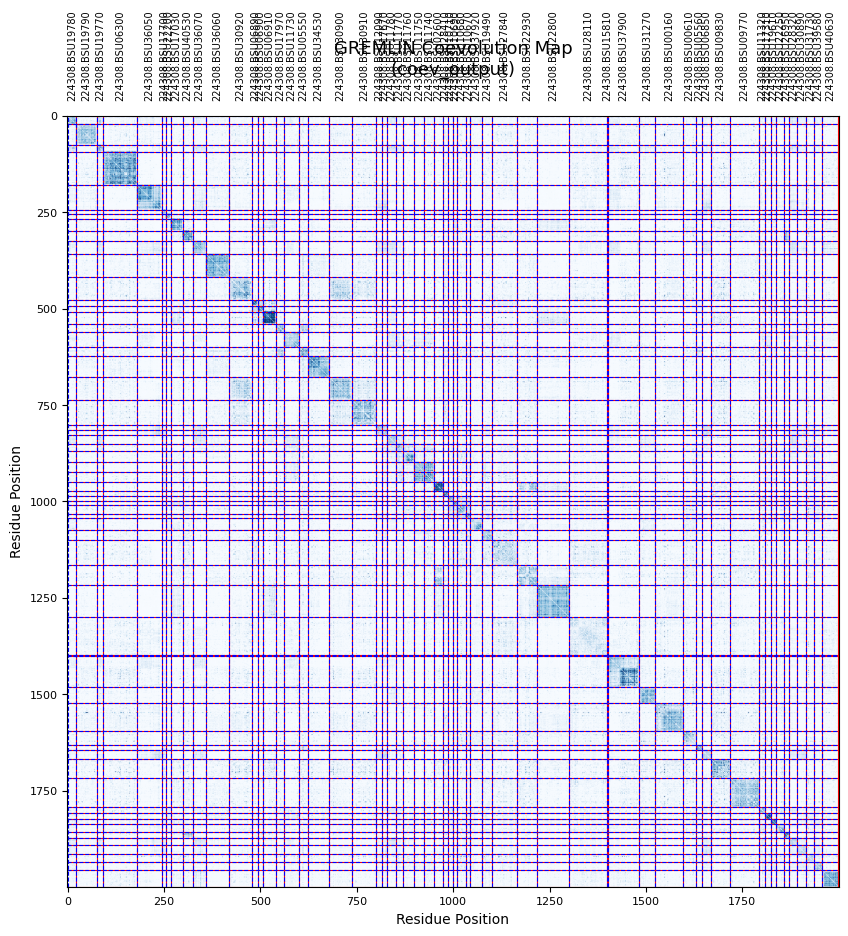

In [ ]:
mtx = get_mtx(mrf)
plot_mtx(mtx,final_boundaries)

In [ ]:
print("Final MRF length:", mrf_avg["len"])
print("Sum of boundaries:", sum(e - s for _, s, e in final_boundaries))

Final MRF length: 2000
Sum of boundaries: 2000


In [ ]:
print("Keys in mtx:", mtx.keys())
print("zscore shape:", np.shape(mtx.get('apc', None)))
print("zscore stats:")
z = np.array(mtx.get('apc', []))
print("  min:", np.nanmin(z) if len(z) else None)
print("  max:", np.nanmax(z) if len(z) else None)
print("  mean:", np.nanmean(z) if len(z) else None)
gremcheck = (np.nanmean(z) if len(z) else None)

Keys in mtx: dict_keys(['i', 'j', 'raw', 'apc', 'len'])
zscore shape: (1999000,)
zscore stats:
  min: -0.730134824915802
  max: 1.0
  mean: -5.564042404545153e-06


In [ ]:
#@title Data extraction

######################################################################################
# WARNING - WARNING - WARNING
######################################################################################
# - the index starts at 0
# - the "first" position is 0
# - in bioinformatics, the first position of a sequence is often "1"
#   for this index use i_aa and j_aa!

# adding amino acid to index+1 this is done again in the next step #message from Chris LB Graham
seq = seqs[0]
mtx["i_aa"] = [f"{seq[i]}_{i+1}" for i in mtx["i"]]
mtx["j_aa"] = [f"{seq[j]}_{j+1}" for j in mtx["j"]]

# load mtx into pandas dataframe
pd_mtx = pd.DataFrame(mtx,columns=["i","j","raw","apc","i_aa","j_aa"])
coev_mtx = pd.DataFrame(mtx,columns=["i","j","apc"])
# @markdown Please set the threshold to visualise in 3D and display in table form here. Please note that the residues above this threshold will be kept in the 'sorted_values.csv' A threshold of 2.5-3 or more is recommended, based on a limited dataset of available models currently.
import numpy as np
from numpy import load
import pandas as pd
GREM_threshold = gremcheck
# Assuming pd_mtx is your DataFrame
# Extracting columns i, j, and apc into a new DataFrame
new_df = pd_mtx[['i', 'j', 'apc']].copy()
df = new_df
df.columns = ["A", "B", "Score"]
df.to_csv('grem_file.csv', sep=' ', index=False)
df = df[(df['Score'] > GREM_threshold)]
df = df.add([1,1,0])
df = df.sort_values('Score',ascending=False)
df = df.reset_index()
del df['index']
df.to_csv('sorted_file.csv', sep=' ', index=False)


In [ ]:
import pandas as pd
#@title Protein to Protein interaction labelling
# Step 1: Load the grem_file.csv (tab-delimited) and strip any leading/trailing spaces in column names
grem_df = pd.read_csv("sorted_file.csv", sep=" ")
grem_df.columns = grem_df.columns.str.strip()  # Strip spaces from column names

# Display the columns and the first few rows to inspect the data
print("Columns in DataFrame:", grem_df.columns)
print("Initial DataFrame:")
print(grem_df.head())

# Step 3: Function to get segment name based on index
def get_segment_name(index, segment_boundaries):
    for name, start, end in segment_boundaries:
        if start <= index <= end:
            return name
    return None  # Return None if index doesn't match any segment

# Step 4: Add 1 to columns A and B to convert to 1-indexing
grem_df['A'] = grem_df['A'] + 1
grem_df['B'] = grem_df['B'] + 1

# Step 5: Assign segment names based on the new values of A and B
grem_df['name_i'] = grem_df['A'].apply(lambda x: get_segment_name(x, final_boundaries))
grem_df['name_j'] = grem_df['B'].apply(lambda x: get_segment_name(x, final_boundaries))

# The aa_i and aa_j columns will just be the same as columns A and B (after adding 1)
grem_df['aa_i'] = grem_df['A']  # Directly use the index from column A
grem_df['aa_j'] = grem_df['B']  # Directly use the index from column B

# Display the updated DataFrame with the new columns
print("Updated DataFrame:")
print(grem_df.head())

# Step 6: Save the updated DataFrame to a new CSV
# Write the result to a new tab-delimited CSV
grem_df[['name_i', 'name_j', 'aa_i', 'aa_j', 'Score']].to_csv('updated_grem_file_with_names.csv', sep="\t", index=False)

print("Updated CSV file has been saved as 'updated_grem_file_with_names.csv'.")


Columns in DataFrame: Index(['A', 'B', 'Score'], dtype='object')
Initial DataFrame:
      A     B     Score
0   980   983  1.000000
1   512   524  0.894370
2   512   538  0.872975
3  1679  1702  0.851485
4  1442  1470  0.841685
Updated DataFrame:
      A     B     Score           name_i           name_j  aa_i  aa_j
0   981   984  1.000000  224308.BSU28410  224308.BSU28410   981   984
1   513   525  0.894370  224308.BSU06910  224308.BSU06910   513   525
2   513   539  0.872975  224308.BSU06910  224308.BSU06910   513   539
3  1680  1703  0.851485  224308.BSU09830  224308.BSU09830  1680  1703
4  1443  1471  0.841685  224308.BSU37900  224308.BSU37900  1443  1471
Updated CSV file has been saved as 'updated_grem_file_with_names.csv'.


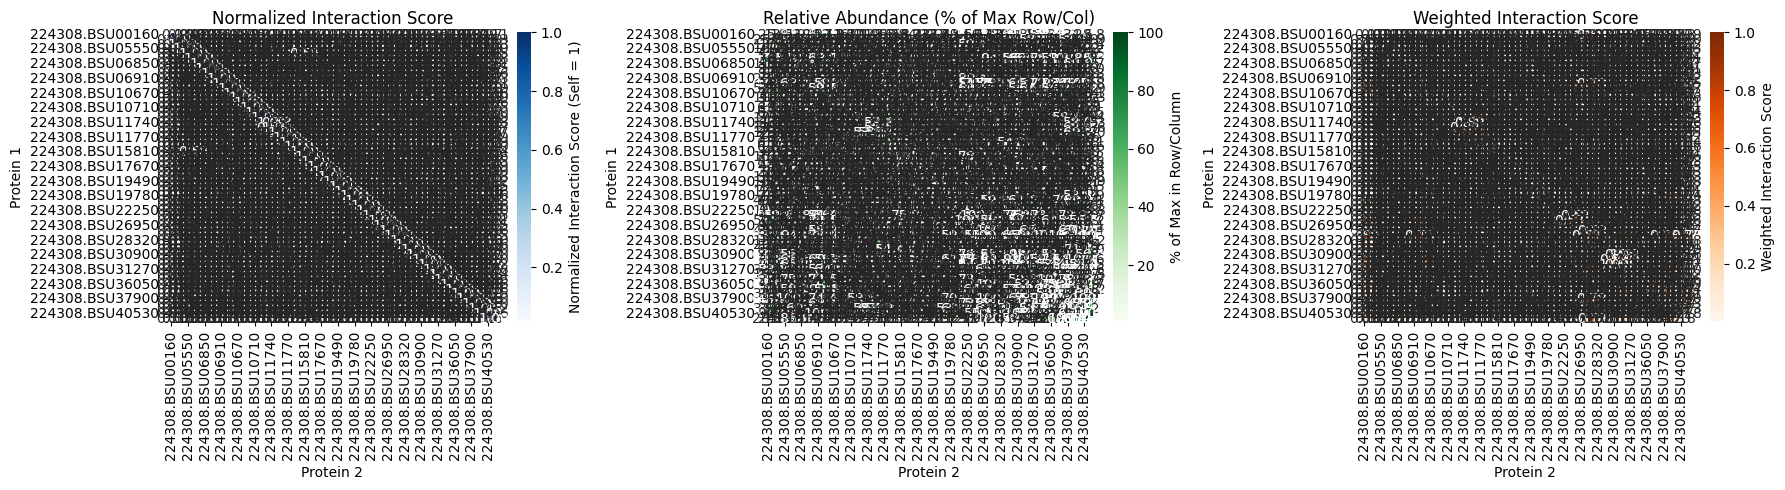

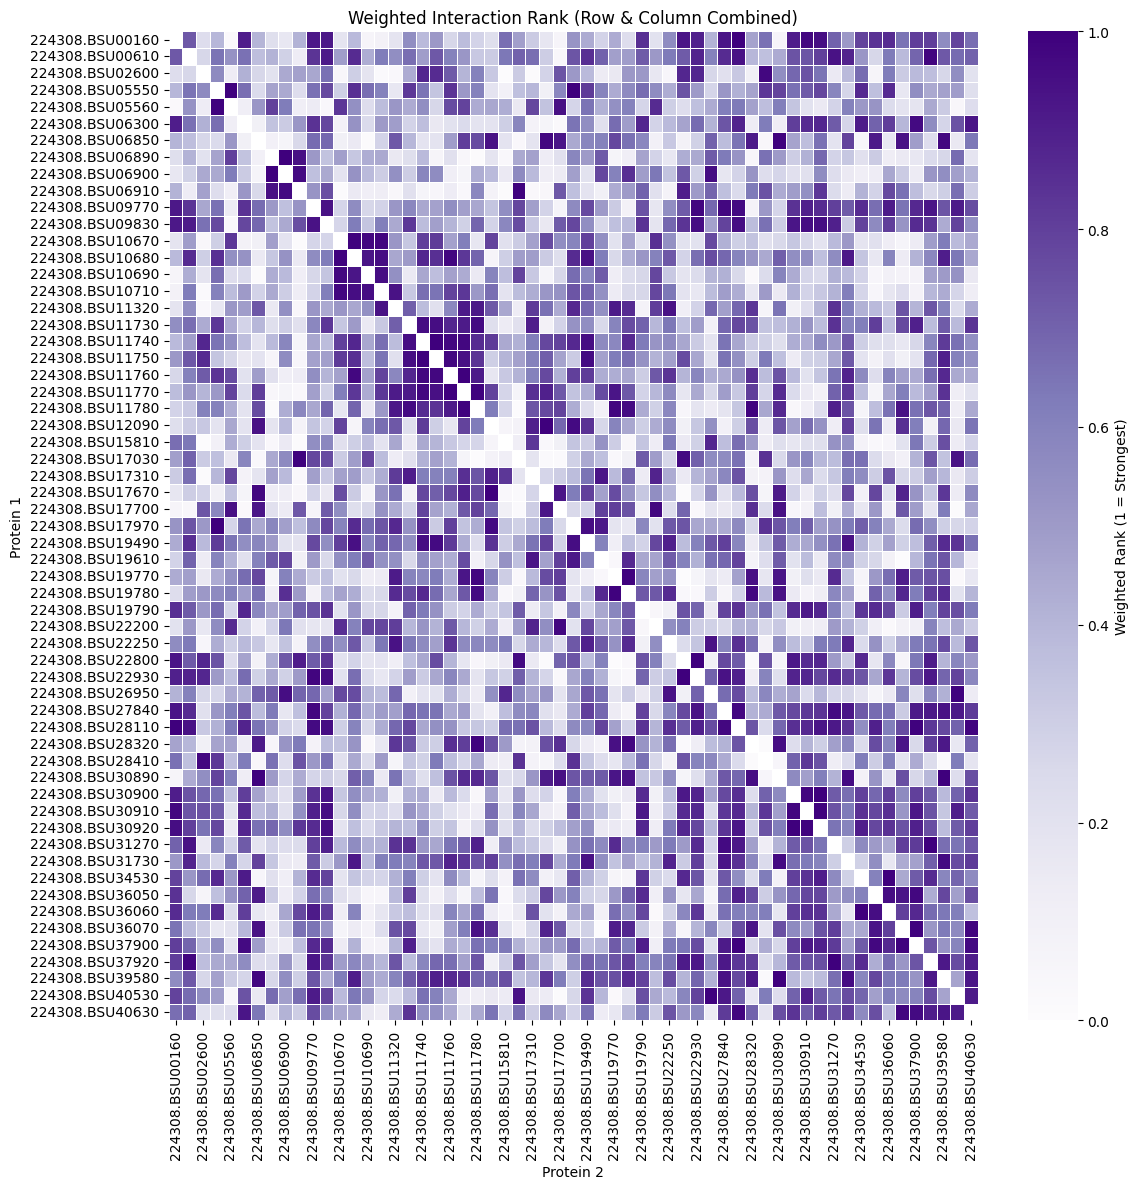

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load the updated GREM file
# -----------------------------
updated_grem_df = pd.read_csv("updated_grem_file_with_names.csv", sep="\t")

# -----------------------------
# Step 2: Average score per protein pair
# -----------------------------
average_scores = (
    updated_grem_df
    .groupby(['name_i', 'name_j'])['Score']
    .mean()
    .reset_index()
)

# -----------------------------
# Step 3: Create pivot matrix
# -----------------------------
score_matrix = average_scores.pivot(index='name_i', columns='name_j', values='Score').fillna(0)

# -----------------------------
# Step 4: Self-normalization (self=1)
# -----------------------------
normalized_matrix = score_matrix.copy()
for name in score_matrix.index:
    if name in score_matrix.columns and score_matrix.loc[name, name] != 0:
        normalized_matrix.loc[name, :] = score_matrix.loc[name, :] / score_matrix.loc[name, name]
    else:
        normalized_matrix.loc[name, :] = 0
np.fill_diagonal(normalized_matrix.values, 1.0)

# -----------------------------
# Step 5: Build symmetric interaction matrix
# -----------------------------
long_format = normalized_matrix.reset_index().melt(
    id_vars=['name_i'], var_name='protein2', value_name='score'
)
long_format.rename(columns={'name_i': 'protein1'}, inplace=True)
df_reversed = long_format.rename(columns={'protein1': 'protein2', 'protein2': 'protein1'})
df_combined = pd.concat([long_format, df_reversed], ignore_index=True)
df_combined = df_combined.groupby(['protein1', 'protein2'], as_index=False)['score'].mean()
interaction_matrix = df_combined.pivot(index='protein1', columns='protein2', values='score')
interaction_matrix = interaction_matrix.combine_first(interaction_matrix.T)

# -----------------------------
# Step 6: Count interactions per protein pair (symmetric)
# -----------------------------
df_rev = updated_grem_df.rename(columns={'name_i': 'name_j', 'name_j': 'name_i'})
df_counts = pd.concat([updated_grem_df, df_rev], ignore_index=True)
pair_counts = df_counts.groupby(['name_i', 'name_j']).size().reset_index(name='n_interactions')
pair_counts_matrix = pair_counts.pivot(index='name_i', columns='name_j', values='n_interactions').fillna(0)

# -----------------------------
# Step 7: Compute % relative to max in row or column (excluding self)
# -----------------------------
percentage_matrix = pair_counts_matrix.copy().astype(float)
np.fill_diagonal(percentage_matrix.values, np.nan)

for i in percentage_matrix.index:
    for j in percentage_matrix.columns:
        if i != j:
            row_max = percentage_matrix.loc[i, :].max(skipna=True)
            col_max = percentage_matrix.loc[:, j].max(skipna=True)
            max_val = max(row_max, col_max)
            if max_val != 0:
                percentage_matrix.loc[i, j] = (percentage_matrix.loc[i, j] / max_val) * 100
            else:
                percentage_matrix.loc[i, j] = 0

# -----------------------------
# Step 8: Compute weighted interaction score
# -----------------------------
normalized_aligned = interaction_matrix.reindex(
    index=percentage_matrix.index,
    columns=percentage_matrix.columns
).fillna(0)

weighted_matrix = normalized_aligned * (percentage_matrix / 100)
weighted_matrix = (weighted_matrix + weighted_matrix.T) / 2
weighted_matrix_scaled = weighted_matrix / weighted_matrix.max().max()

# -----------------------------
# Step 9: Plot heatmaps with values
# -----------------------------
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(
    interaction_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Interaction Score (Self = 1)'}
)
plt.title('Normalized Interaction Score')
plt.xlabel('Protein 2')
plt.ylabel('Protein 1')

plt.subplot(1, 3, 2)
sns.heatmap(
    percentage_matrix,
    annot=True,
    fmt=".1f",
    cmap='Greens',
    linewidths=0.5,
    cbar_kws={'label': '% of Max in Row/Column'}
)
plt.title('Relative Abundance (% of Max Row/Col)')
plt.xlabel('Protein 2')
plt.ylabel('Protein 1')

plt.subplot(1, 3, 3)
sns.heatmap(
    weighted_matrix_scaled,
    annot=True,
    fmt=".2f",
    cmap='Oranges',
    linewidths=0.5,
    cbar_kws={'label': 'Weighted Interaction Score'}
)
plt.title('Weighted Interaction Score')
plt.xlabel('Protein 2')
plt.ylabel('Protein 1')

plt.tight_layout()
plt.show()

# -----------------------------
# Step 9b: Rank-based interaction matrix (based on WEIGHTED values)
# -----------------------------
# Rank within each row and each column (1 = strongest weighted interaction)
rank_by_row = weighted_matrix.rank(axis=1, ascending=False, method='average')
rank_by_col = weighted_matrix.rank(axis=0, ascending=False, method='average')

# Combine row and column ranks symmetrically
weighted_rank_matrix = (rank_by_row + rank_by_col) / 2

# Normalize for plotting: 1 = strongest, 0 = weakest
weighted_rank_norm = 1 - (weighted_rank_matrix - 1) / (weighted_rank_matrix.max().max() - 1)

# Plot rank-based heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(
    weighted_rank_norm,
    annot=False,
    cmap='Purples',
    linewidths=0.5,
    cbar_kws={'label': 'Weighted Rank (1 = Strongest)'}
)
plt.title('Weighted Interaction Rank (Row & Column Combined)')
plt.xlabel('Protein 2')
plt.ylabel('Protein 1')
plt.tight_layout()
plt.show()

# Save to CSV
weighted_rank_matrix.to_csv('weighted_interaction_rank_matrix.csv', sep="\t")
weighted_matrix_scaled.to_csv('weighted_interaction_matrix.csv', sep="\t")
interaction_matrix.to_csv('interaction_rank_matrix.csv', sep="\t")


In [ ]:
#@title More info
#@markdown Network of the CoEvMapper interaction scores, with each protein labelled from the best
#@markdown source available, in this order:
#@markdown 1. **Your FASTA header** - e.g. `>WP_004296482.1|I5Q79_RS12240 Versailles prophage ORF,
#@markdown    HU family DNA-binding protein (3019715-3019987, strand +)` gives "HU family DNA-binding
#@markdown    protein" (`HEADER_LABEL_PART` = "after first comma") or the whole description without
#@markdown    the coordinates ("full description").
#@markdown 2. **NCBI** - the protein record for the accession in the header (e.g. WP_004296482.1):
#@markdown    gene name + product.
#@markdown 3. **STRING** - only for STRING-style ids ("224308.BSU24430"), which NCBI can't look up.
#@markdown 4. **Nickname** - anything none of the above can name gets a short nickname,
#@markdown    Gene A, Gene B, ... (then Gene AA, AB, ... past Z); hover still shows its full
#@markdown    id and header text, and a key of nickname -> id is printed below the labels.
#@markdown
#@markdown `LABEL_STYLE`: "common name" puts a real gene name (e.g. hupB) on the node when one
#@markdown exists, otherwise the description; "description" always uses the description. Gene
#@markdown "names" that are really locus tags (BSU36420, I5Q79_RS12240) don't count as names.

import pandas as pd
import plotly.graph_objects as go
import networkx as nx
import random
import os
import re
import time
import requests
from io import StringIO
from collections import defaultdict

from Bio import Entrez, SeqIO

# ==========================================================
# PARAMETERS
# ==========================================================

MIN_EDGE_SCORE = 0.2   #@param
LABEL_STYLE = "common name"  #@param ["common name", "description"]
HEADER_LABEL_PART = "after first comma"  #@param ["after first comma", "full description"]
EDGE_WIDTH_SCALE = 10  # visual scaling

NCBI_EMAIL = "chris.l.b.graham@warwick.ac.uk"
STRING_API = "https://string-db.org/api"
STRING_CALLER = "coevfold_coevmapper_labels"

# Network lookups (NCBI / STRING) are cached per protein and per source, so
# changing the label options above and re-running is instant; only new proteins get queried.
ANNOTATION_CACHE = "protein_annotation_cache_v3.csv"

Entrez.email = NCBI_EMAIL


# ==========================================================
# Step 1. Load interaction matrix
# ==========================================================

interaction_df = pd.read_csv(
    'weighted_interaction_matrix.csv',
    sep='\t',
    index_col=0
)


# ==========================================================
# Step 2. Text helpers
# ==========================================================

def clean_accession(accession):

    accession = str(accession).strip()

    # Handle headers such as:
    # sp|P12345|NAME
    # WP_012345.1
    # WP_012345

    if "|" in accession:

        parts = accession.split("|")

        for part in parts:

            if (
                part.startswith("WP_") or
                re.match(r"^[A-Z]{2}_\d+", part) or
                re.match(r"^[A-Z]{1,5}\d+\.\d+$", part)
            ):
                accession = part
                break

    accession = accession.split()[0]

    return accession


def string_native_taxon(accession):
    """Taxon id if `accession` is a STRING id ("224308.BSU24430"), else None."""
    m = re.match(r"^(\d+)\.(\S+)$", str(accession))
    return m.group(1) if m else None


def looks_like_ncbi_accession(accession):
    """RefSeq (WP_/NP_/XP_...), GenBank protein (ABC12345) or UniProt (P12345) accession -
    i.e. something NCBI's protein database can fetch. Locus tags (I5Q79_RS12240, BSU24430)
    are not, and are kept out of the batched NCBI request so they can't break it."""
    return bool(re.match(
        r"^([A-Z]{2}_\d+|[A-Z]{3}\d{5}|[OPQ]\d[A-Z0-9]{3}\d|[A-NR-Z]\d[A-Z][A-Z0-9]{2}\d)(\.\d+)?$",
        str(accession)))


def versionless(accession):
    m = re.match(r"^([A-Z]{1,3}_?\d+)\.\d+$", str(accession))
    return m.group(1) if m else accession


def is_uninformative_annotation(product):

    if product is None:
        return True

    p = str(product).lower().strip()

    uninformative_terms = [
        "hypothetical protein",
        "uncharacterized protein",
        "uncharacterised protein",
        "unknown protein",
        "unnamed protein",
        "conserved hypothetical protein",
        "predicted protein",
        "protein of unknown function",
        "domain of unknown function"
    ]

    return (
        p == "" or
        p in ("partial", "fragment", "putative", "protein") or
        any(term in p for term in uninformative_terms)
    )


def looks_like_locus_tag(name, accession=""):
    """True for 'names' that are really ids: BSU36420, I5Q79_RS12240, b1234, or the accession."""
    if not name:
        return True
    name = str(name)
    return (name == str(accession) or "_" in name or bool(re.search(r"\d{3,}", name)))


def shorten_annotation(product):

    if product is None:
        return None

    product = str(product).strip()

    # Swiss-Prot style "RecName: Full=DNA-binding protein HU; AltName: ..." -> the Full= name
    m = re.search(r"Full=([^;\[]+)", product)
    if m:
        product = m.group(1)

    # Remove organism name
    product = re.sub(r"\s+\[[^\]]+\]\s*$", "", product)

    # Remove common annotation prefixes
    product = re.sub(r"^(MULTISPECIES:\s*)", "", product, flags=re.IGNORECASE)
    product = re.sub(r"^(LOW QUALITY PROTEIN:\s*)", "", product, flags=re.IGNORECASE)
    product = re.sub(r"^(PREDICTED:\s*)", "", product, flags=re.IGNORECASE)

    # STRING descriptions are often several clauses; the first clause is the name
    product = re.split(r";\s*", product)[0]

    product = product.strip()

    return product or None


def _clean(value):
    """None / NaN / empty -> None, otherwise a stripped string."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    value = str(value).strip()
    return value or None


# ==========================================================
# Step 3. Your FASTA headers (instant, no lookup)
# ==========================================================

# "(3019715-3019987, strand +)"-style coordinate suffix at the end of a header
COORD_SUFFIX = re.compile(r"\s*\(\s*\d+\s*(-|\.\.)\s*\d+[^()]*\)\s*$")


def header_description(record):
    """Free text after the id in the FASTA header, coordinates removed."""
    desc = record.description or ""
    if desc.startswith(record.id):
        desc = desc[len(record.id):]
    desc = COORD_SUFFIX.sub("", desc.strip()).strip()
    return desc or None


# A comma that separates text - with or without a space after it - but NOT one between two
# digits, so chemical names like "2,3-bisphosphoglycerate" are never cut in half.
TEXT_COMMA = re.compile(r"(?<!\d),|,(?!\d)")


QUALIFIERS = {"partial", "fragment", "putative"}


def header_label_text(desc, for_fallback=False):
    """'Versailles prophage ORF, HU family DNA-binding protein' -> 'HU family DNA-binding
    protein': everything after the FIRST comma is the protein (so a protein name that itself
    contains a comma, e.g. 'ATP synthase subunit alpha, mitochondrial', stays whole).
    - 'X, partial' / 'X, fragment' -> 'X' (just a qualifier after the comma).
    - 'Versailles prophage ORF, hypothetical protein' -> 'hypothetical protein', which counts as
      unannotated so NCBI / STRING still get a go (and if they find nothing, the protein
      gets a nickname - the header text stays in the hover).
    "full description" keeps the whole header text (minus coordinates)."""
    if not desc:
        return None
    if HEADER_LABEL_PART == "full description":
        return shorten_annotation(desc)
    parts = TEXT_COMMA.split(desc, maxsplit=1)
    if len(parts) < 2:
        return shorten_annotation(desc)
    before, after = parts[0].strip(), parts[1].strip()
    if not after or after.lower() in QUALIFIERS:
        chosen = before
    elif is_uninformative_annotation(after):
        chosen = (before or after) if for_fallback else after
    else:
        chosen = after
    return shorten_annotation(chosen)


fasta_records = globals().get("records") or []
_simplify = globals().get("simplify_header")

header_lookup = {}  # any id/name a protein might appear under -> header info

for rec in fasta_records:
    rec_id = str(rec.id)
    info = {
        "header_description": header_description(rec),
        "sequence": re.sub(r"[^A-Z]", "", str(rec.seq).upper()),
        "ncbi_accession": None,
    }
    keys = {rec_id, clean_accession(rec_id)}
    for part in rec_id.split("|"):
        part = part.strip()
        if not part:
            continue
        keys.add(part)
        if info["ncbi_accession"] is None and looks_like_ncbi_accession(part):
            info["ncbi_accession"] = part
    if _simplify is not None:
        try:
            keys.add(str(_simplify(rec)))
        except Exception:
            pass
    for k in list(keys):
        keys.add(versionless(k))
    for k in keys:
        header_lookup.setdefault(k, info)

if not fasta_records:
    print("Note: no FASTA `records` in memory (run the upload cell first) - header labels, "
          "and header accessions won't be available this run.")


def find_header(node):
    for key in (node, clean_accession(node), versionless(clean_accession(node))):
        if key in header_lookup:
            return header_lookup[key]
    return {}


# ==========================================================
# Step 4. Lookups: NCBI, STRING
# ==========================================================

def fetch_ncbi_protein_records(accessions):
    """{accession: {"common_name", "description"}} from NCBI GenBank protein records.
    One batched request; if NCBI rejects the batch, falls back to one request per id."""

    accessions = list(dict.fromkeys(accessions))
    records = {}
    if not accessions:
        return records

    def _parse(data):
        for record in SeqIO.parse(StringIO(data), "genbank"):
            accession = None
            if record.annotations.get("accessions"):
                accession = record.annotations["accessions"][0]
            if accession is None:
                accession = record.id
            product = gene = None
            for feature in record.features:
                if product is None and feature.qualifiers.get("product"):
                    product = feature.qualifiers["product"][0]
                if gene is None and feature.qualifiers.get("gene"):
                    gene = feature.qualifiers["gene"][0]
            if product is None:
                product = record.description
            entry = {"common_name": gene, "description": shorten_annotation(product)}
            for key in (accession, record.id, versionless(accession), versionless(record.id)):
                records.setdefault(key, entry)

    def _efetch(ids):
        handle = Entrez.efetch(db="protein", id=",".join(ids), rettype="gb", retmode="text")
        data = handle.read()
        handle.close()
        return data

    print(f"Fetching {len(accessions)} protein records from NCBI...")
    try:
        _parse(_efetch(accessions))
    except Exception as e:
        print(f"  batched NCBI request failed ({e}) - retrying one at a time")
        for acc in accessions:
            try:
                _parse(_efetch([acc]))
            except Exception as e2:
                print(f"  NCBI lookup failed for {acc}: {e2}")
            time.sleep(0.34)  # NCBI etiquette without an API key

    return records


def fetch_string_annotations(accessions):
    """{accession: {"common_name", "description"}} for STRING-style ids, one request per species.
    Ids joined with a real carriage return (the literal text "%0d" gets double-encoded)."""

    records = {}
    by_taxon = defaultdict(list)
    for acc in accessions:
        by_taxon[string_native_taxon(acc)].append(acc)

    for taxon_id, accs in by_taxon.items():
        print(f"Fetching {len(accs)} protein names from STRING (taxon {taxon_id})...")
        try:
            resp = requests.get(
                f"{STRING_API}/tsv/get_string_ids",
                params={"identifiers": "\r".join(accs), "species": taxon_id, "limit": 1,
                        "echo_query": 1, "caller_identity": STRING_CALLER},
                timeout=30)
            resp.raise_for_status()
            df = pd.read_csv(StringIO(resp.text), sep="\t")
        except Exception as e:
            print(f"  STRING lookup failed for taxon {taxon_id}: {e}")
            continue
        for _, r in df.iterrows():
            query = str(r.get("queryItem", r.get("stringId")))
            records[query] = {"common_name": r.get("preferredName"),
                              "description": shorten_annotation(r.get("annotation"))}
        time.sleep(1)  # STRING etiquette: max 1 request/sec

    return records


# ==========================================================
# Step 5. Proteins in the network + cache
# ==========================================================

network_accessions = sorted(
    set(interaction_df.index.astype(str)) | set(interaction_df.columns.astype(str))
)
network_accessions = [clean_accession(x) for x in network_accessions]
print(f"Proteins in network: {len(network_accessions)}")

cache = {}  # (accession, source) -> {"common_name", "description", "detail"}

if os.path.exists(ANNOTATION_CACHE):
    try:
        for _, row in pd.read_csv(ANNOTATION_CACHE).iterrows():
            cache[(str(row["accession"]), str(row["source"]))] = {
                "common_name": _clean(row.get("common_name")),
                "description": _clean(row.get("description")),
                "detail": _clean(row.get("detail")),
            }
        print(f"Loaded {len(cache)} cached lookups.")
    except Exception as e:
        print(f"Could not read annotation cache: {e}")


# ==========================================================
# Step 6. Run whatever lookups aren't cached yet
# ==========================================================

ncbi_acc_for = {}
for acc in network_accessions:
    hdr = find_header(acc)
    if hdr.get("ncbi_accession"):
        ncbi_acc_for[acc] = hdr["ncbi_accession"]
    elif looks_like_ncbi_accession(acc):
        ncbi_acc_for[acc] = acc

need_ncbi = [acc for acc in network_accessions
             if acc in ncbi_acc_for and (acc, "NCBI") not in cache]
if need_ncbi:
    found = fetch_ncbi_protein_records([ncbi_acc_for[a] for a in need_ncbi])
    for acc in need_ncbi:
        ncbi_acc = ncbi_acc_for[acc]
        rec = found.get(ncbi_acc) or found.get(versionless(ncbi_acc))
        if rec:  # failures aren't cached, so they're retried next run
            cache[(acc, "NCBI")] = {"common_name": _clean(rec["common_name"]),
                                    "description": _clean(rec["description"]),
                                    "detail": ncbi_acc}

need_string = [acc for acc in network_accessions
               if string_native_taxon(acc) and (acc, "STRING") not in cache]
if need_string:
    found = fetch_string_annotations(need_string)
    for acc in need_string:
        if acc in found:
            cache[(acc, "STRING")] = {"common_name": _clean(found[acc]["common_name"]),
                                      "description": _clean(found[acc]["description"]),
                                      "detail": None}


def informative_description(acc):
    """Best informative description: header, then NCBI, then STRING."""
    hdr_text = header_label_text(find_header(acc).get("header_description"))
    for source, text in (("FASTA header", hdr_text),
                         ("NCBI", (cache.get((acc, "NCBI")) or {}).get("description")),
                         ("STRING", (cache.get((acc, "STRING")) or {}).get("description"))):
        if text and not is_uninformative_annotation(text):
            return source, text
    return None, None


pd.DataFrame(
    [{"accession": a, "source": s, **v} for (a, s), v in cache.items()],
    columns=["accession", "source", "common_name", "description", "detail"],
).to_csv(ANNOTATION_CACHE, index=False)


# ==========================================================
# Step 7. Pick each protein's label
# ==========================================================

def nickname_letters(i):
    """0 -> A, 25 -> Z, 26 -> AA, 27 -> AB, ..."""
    letters = ""
    i += 1
    while i:
        i, r = divmod(i - 1, 26)
        letters = chr(65 + r) + letters
    return letters


annotation_rows = []
n_nicknamed = 0

for acc in network_accessions:

    hdr = find_header(acc)
    ncbi = cache.get((acc, "NCBI")) or {}
    string = cache.get((acc, "STRING")) or {}

    # Real gene name: NCBI first, then STRING - locus-tag-like "names" don't count
    gene = None
    for candidate in (ncbi.get("common_name"), string.get("common_name")):
        if candidate and not looks_like_locus_tag(candidate, acc):
            gene = candidate
            break

    desc_source, description = informative_description(acc)

    if LABEL_STYLE == "common name" and gene:
        label, label_source = gene, ("NCBI" if gene == ncbi.get("common_name") else "STRING")
    elif description:
        label, label_source = description, desc_source
    elif gene:
        label, label_source = gene, "NCBI/STRING"
    else:
        # nothing informative anywhere - short nickname instead of a long id / "hypothetical"
        label, label_source = f"Gene {nickname_letters(n_nicknamed)}", "nickname"
        n_nicknamed += 1

    annotation_rows.append({
        "accession": acc,
        "label": label,
        "label_source": label_source,
        "gene": gene,
        "header_description": hdr.get("header_description"),
        "ncbi_description": ncbi.get("description"),
        "string_description": string.get("description"),
    })

annotation_df = pd.DataFrame(annotation_rows)
annotation_df.to_csv("protein_labels.csv", index=False)

print("\n" + "=" * 80)
print("PROTEIN LABELS")
print("=" * 80)
for _, row in annotation_df.iterrows():
    print(f"{row['accession']:22s} -> {row['label']}  [{row['label_source']}]")

nicknamed = annotation_df[annotation_df["label_source"] == "nickname"]
if len(nicknamed):
    print(f"\nNicknames ({len(nicknamed)} proteins with no informative name anywhere):")
    for _, row in nicknamed.iterrows():
        extra = f"  - {row['header_description']}" if _clean(row["header_description"]) else ""
        print(f"  {row['label']:8s} = {row['accession']}{extra}")


# ==========================================================
# Step 8. Convert pivot matrix to long format
# ==========================================================

edges_long = (
    interaction_df
    .reset_index()
    .melt(id_vars=interaction_df.index.name, var_name='protein2', value_name='score')
    .rename(columns={interaction_df.index.name: 'protein1'})
)

# Remove self-interactions and zeros
edges_long = edges_long[
    (edges_long['protein1'] != edges_long['protein2']) &
    (edges_long['score'] > 0)
]


# ==========================================================
# Step 9. Create NetworkX graph
# ==========================================================

G = nx.Graph()

for _, row in edges_long.iterrows():
    if row['score'] >= MIN_EDGE_SCORE:
        G.add_edge(
            clean_accession(row['protein1']),
            clean_accession(row['protein2']),
            weight=row['score']
        )

pos = nx.spring_layout(G, k=0.35, weight='weight', iterations=200, seed=42)


# ==========================================================
# Step 10. Edge traces
# ==========================================================

edge_traces = []

for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_traces.append(go.Scatter(
        x=[x0, x1, None],
        y=[y0, y1, None],
        line=dict(width=d['weight'] * EDGE_WIDTH_SCALE, color='#999'),
        hoverinfo='none',
        mode='lines'
    ))


# ==========================================================
# Step 11. Node trace
# ==========================================================

node_x, node_y, node_labels, node_colors, node_sizes, node_hover = [], [], [], [], [], []

annotation_lookup = annotation_df.set_index('accession').to_dict('index')

for node in G.nodes():

    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    a = annotation_lookup.get(clean_accession(node), {})
    label = a.get("label", node)
    node_labels.append(label)

    hover = [f"<b>{label}</b>", f"ID: {node}", f"Label from: {a.get('label_source', '-')}"]
    for title, key in (("Gene", "gene"), ("FASTA header", "header_description"),
                       ("NCBI", "ncbi_description"), ("STRING", "string_description")):
        value = _clean(a.get(key))
        if value:
            hover.append(f"{title}: {value}")
    node_hover.append("<br>".join(hover))

    node_colors.append(
        f'rgba({random.randint(50,200)},{random.randint(50,200)},{random.randint(50,200)},0.9)'
    )
    node_sizes.append(10 + 2 * G.degree[node])

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    marker=dict(color=node_colors, size=node_sizes, line=dict(width=1, color='black')),
    text=node_labels,
    textposition='top center',
    hovertext=node_hover,
    hoverinfo='text'
)


# ==========================================================
# Step 12. Plot
# ==========================================================

fig = go.Figure(
    data=edge_traces + [node_trace],
    layout=go.Layout(
        title=dict(text="Protein–Protein Interaction Network (Self-Normalized)",
                   font=dict(size=26)),
        font_size=16,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
)

fig.show()

Proteins in network: 59
Fetching 59 protein names from STRING (taxon 224308)...

PROTEIN LABELS
224308.BSU00160        -> yaaH  [STRING]
224308.BSU00610        -> yabQ  [STRING]
224308.BSU02600        -> cwlJ  [STRING]
224308.BSU05550        -> cotP  [STRING]
224308.BSU05560        -> ydgA  [STRING]
224308.BSU06300        -> cotA  [STRING]
224308.BSU06850        -> yeeK  [STRING]
224308.BSU06890        -> cotJA  [STRING]
224308.BSU06900        -> cotJB  [STRING]
224308.BSU06910        -> cotJC  [STRING]
224308.BSU09770        -> yheD  [STRING]
224308.BSU09830        -> yhaX  [STRING]
224308.BSU10670        -> gerPF  [STRING]
224308.BSU10680        -> gerPE  [STRING]
224308.BSU10690        -> gerPD  [STRING]
224308.BSU10710        -> gerPB  [STRING]
224308.BSU11320        -> yjzB  [STRING]
224308.BSU11730        -> cotO  [STRING]
224308.BSU11740        -> cotZ  [STRING]
224308.BSU11750        -> cotY  [STRING]
224308.BSU11760        -> cotX  [STRING]
224308.BSU11770        -> cotW  [STR

In [ ]:
#@title More info
#@markdown Network of the CoEvMapper interaction scores, with each protein labelled from the best
#@markdown source available, in this order:
#@markdown 1. **Your FASTA header** - e.g. `>WP_004296482.1|I5Q79_RS12240 Versailles prophage ORF,
#@markdown    HU family DNA-binding protein (3019715-3019987, strand +)` gives "HU family DNA-binding
#@markdown    protein" (`HEADER_LABEL_PART` = "after last comma") or the whole description without
#@markdown    the coordinates ("full description").
#@markdown 2. **NCBI** - the protein record for the accession in the header (e.g. WP_004296482.1):
#@markdown    gene name + product.
#@markdown 3. **STRING** - only for STRING-style ids ("224308.BSU24430"), which NCBI can't look up.
#@markdown 4. **Nickname** - anything none of the above can name gets a short nickname,
#@markdown    Gene A, Gene B, ... (then Gene AA, AB, ... past Z); hover still shows its full
#@markdown    id and header text, and a key of nickname -> id is printed below the labels.
#@markdown
#@markdown `LABEL_STYLE`: "common name" puts a real gene name (e.g. hupB) on the node when one
#@markdown exists, otherwise the description; "description" always uses the description. Gene
#@markdown "names" that are really locus tags (BSU36420, I5Q79_RS12240) don't count as names.

import pandas as pd
import plotly.graph_objects as go
import networkx as nx
import random
import os
import re
import time
import requests
from io import StringIO
from collections import defaultdict

from Bio import Entrez, SeqIO

# ==========================================================
# PARAMETERS
# ==========================================================

MIN_EDGE_SCORE = 0.2   #@param
LABEL_STYLE = "common name"  #@param ["common name", "description"]
HEADER_LABEL_PART = "after last comma"  #@param ["after last comma", "full description"]
EDGE_WIDTH_SCALE = 10  # visual scaling

NCBI_EMAIL = "chris.l.b.graham@warwick.ac.uk"
STRING_API = "https://string-db.org/api"
STRING_CALLER = "coevfold_coevmapper_labels"

# Network lookups (NCBI / STRING) are cached per protein and per source, so
# changing the label options above and re-running is instant; only new proteins get queried.
ANNOTATION_CACHE = "protein_annotation_cache_v3.csv"

Entrez.email = NCBI_EMAIL


# ==========================================================
# Step 1. Load interaction matrix
# ==========================================================

interaction_df = pd.read_csv(
    'weighted_interaction_matrix.csv',
    sep='\t',
    index_col=0
)


# ==========================================================
# Step 2. Text helpers
# ==========================================================

def clean_accession(accession):

    accession = str(accession).strip()

    # Handle headers such as:
    # sp|P12345|NAME
    # WP_012345.1
    # WP_012345

    if "|" in accession:

        parts = accession.split("|")

        for part in parts:

            if (
                part.startswith("WP_") or
                re.match(r"^[A-Z]{2}_\d+", part) or
                re.match(r"^[A-Z]{1,5}\d+\.\d+$", part)
            ):
                accession = part
                break

    accession = accession.split()[0]

    return accession


def string_native_taxon(accession):
    """Taxon id if `accession` is a STRING id ("224308.BSU24430"), else None."""
    m = re.match(r"^(\d+)\.(\S+)$", str(accession))
    return m.group(1) if m else None


def looks_like_ncbi_accession(accession):
    """RefSeq (WP_/NP_/XP_...), GenBank protein (ABC12345) or UniProt (P12345) accession -
    i.e. something NCBI's protein database can fetch. Locus tags (I5Q79_RS12240, BSU24430)
    are not, and are kept out of the batched NCBI request so they can't break it."""
    return bool(re.match(
        r"^([A-Z]{2}_\d+|[A-Z]{3}\d{5}|[OPQ]\d[A-Z0-9]{3}\d|[A-NR-Z]\d[A-Z][A-Z0-9]{2}\d)(\.\d+)?$",
        str(accession)))


def versionless(accession):
    m = re.match(r"^([A-Z]{1,3}_?\d+)\.\d+$", str(accession))
    return m.group(1) if m else accession


def is_uninformative_annotation(product):

    if product is None:
        return True

    p = str(product).lower().strip()

    uninformative_terms = [
        "hypothetical protein",
        "uncharacterized protein",
        "uncharacterised protein",
        "unknown protein",
        "unnamed protein",
        "conserved hypothetical protein",
        "predicted protein",
        "protein of unknown function",
        "domain of unknown function"
    ]

    return (
        p == "" or
        p in ("partial", "fragment", "putative", "protein") or
        any(term in p for term in uninformative_terms)
    )


def looks_like_locus_tag(name, accession=""):
    """True for 'names' that are really ids: BSU36420, I5Q79_RS12240, b1234, or the accession."""
    if not name:
        return True
    name = str(name)
    return (name == str(accession) or "_" in name or bool(re.search(r"\d{3,}", name)))


def shorten_annotation(product):

    if product is None:
        return None

    product = str(product).strip()

    # Swiss-Prot style "RecName: Full=DNA-binding protein HU; AltName: ..." -> the Full= name
    m = re.search(r"Full=([^;\[]+)", product)
    if m:
        product = m.group(1)

    # Remove organism name
    product = re.sub(r"\s+\[[^\]]+\]\s*$", "", product)

    # Remove common annotation prefixes
    product = re.sub(r"^(MULTISPECIES:\s*)", "", product, flags=re.IGNORECASE)
    product = re.sub(r"^(LOW QUALITY PROTEIN:\s*)", "", product, flags=re.IGNORECASE)
    product = re.sub(r"^(PREDICTED:\s*)", "", product, flags=re.IGNORECASE)

    # STRING descriptions are often several clauses; the first clause is the name
    product = re.split(r";\s*", product)[0]

    product = product.strip()

    return product or None


def _clean(value):
    """None / NaN / empty -> None, otherwise a stripped string."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    value = str(value).strip()
    return value or None


# ==========================================================
# Step 3. Your FASTA headers (instant, no lookup)
# ==========================================================

# "(3019715-3019987, strand +)"-style coordinate suffix at the end of a header
COORD_SUFFIX = re.compile(r"\s*\(\s*\d+\s*(-|\.\.)\s*\d+[^()]*\)\s*$")


def header_description(record):
    """Free text after the id in the FASTA header, coordinates removed."""
    desc = record.description or ""
    if desc.startswith(record.id):
        desc = desc[len(record.id):]
    desc = COORD_SUFFIX.sub("", desc.strip()).strip()
    return desc or None


def header_label_text(desc):
    """'Versailles prophage ORF, HU family DNA-binding protein' -> 'HU family DNA-binding
    protein' (last informative comma-separated part), or the whole thing for "full description".
    Splits only on comma + space, so chemical names like '2,3-bisphosphoglycerate' stay whole."""
    if not desc:
        return None
    if HEADER_LABEL_PART == "full description":
        return shorten_annotation(desc)
    segments = [s.strip() for s in re.split(r",\s+", desc) if s.strip()]
    useful = [s for s in segments if not is_uninformative_annotation(s)]
    chosen = useful[-1] if useful else (segments[-1] if segments else None)
    return shorten_annotation(chosen)


fasta_records = globals().get("records") or []
_simplify = globals().get("simplify_header")

header_lookup = {}  # any id/name a protein might appear under -> header info

for rec in fasta_records:
    rec_id = str(rec.id)
    info = {
        "header_description": header_description(rec),
        "sequence": re.sub(r"[^A-Z]", "", str(rec.seq).upper()),
        "ncbi_accession": None,
    }
    keys = {rec_id, clean_accession(rec_id)}
    for part in rec_id.split("|"):
        part = part.strip()
        if not part:
            continue
        keys.add(part)
        if info["ncbi_accession"] is None and looks_like_ncbi_accession(part):
            info["ncbi_accession"] = part
    if _simplify is not None:
        try:
            keys.add(str(_simplify(rec)))
        except Exception:
            pass
    for k in list(keys):
        keys.add(versionless(k))
    for k in keys:
        header_lookup.setdefault(k, info)

if not fasta_records:
    print("Note: no FASTA `records` in memory (run the upload cell first) - header labels "
          "and header accessions won't be available this run.")


def find_header(node):
    for key in (node, clean_accession(node), versionless(clean_accession(node))):
        if key in header_lookup:
            return header_lookup[key]
    return {}


# ==========================================================
# Step 4. Lookups: NCBI, STRING
# ==========================================================

def fetch_ncbi_protein_records(accessions):
    """{accession: {"common_name", "description"}} from NCBI GenBank protein records.
    One batched request; if NCBI rejects the batch, falls back to one request per id."""

    accessions = list(dict.fromkeys(accessions))
    records = {}
    if not accessions:
        return records

    def _parse(data):
        for record in SeqIO.parse(StringIO(data), "genbank"):
            accession = None
            if record.annotations.get("accessions"):
                accession = record.annotations["accessions"][0]
            if accession is None:
                accession = record.id
            product = gene = None
            for feature in record.features:
                if product is None and feature.qualifiers.get("product"):
                    product = feature.qualifiers["product"][0]
                if gene is None and feature.qualifiers.get("gene"):
                    gene = feature.qualifiers["gene"][0]
            if product is None:
                product = record.description
            entry = {"common_name": gene, "description": shorten_annotation(product)}
            for key in (accession, record.id, versionless(accession), versionless(record.id)):
                records.setdefault(key, entry)

    def _efetch(ids):
        handle = Entrez.efetch(db="protein", id=",".join(ids), rettype="gb", retmode="text")
        data = handle.read()
        handle.close()
        return data

    print(f"Fetching {len(accessions)} protein records from NCBI...")
    try:
        _parse(_efetch(accessions))
    except Exception as e:
        print(f"  batched NCBI request failed ({e}) - retrying one at a time")
        for acc in accessions:
            try:
                _parse(_efetch([acc]))
            except Exception as e2:
                print(f"  NCBI lookup failed for {acc}: {e2}")
            time.sleep(0.34)  # NCBI etiquette without an API key

    return records


def fetch_string_annotations(accessions):
    """{accession: {"common_name", "description"}} for STRING-style ids, one request per species.
    Ids joined with a real carriage return (the literal text "%0d" gets double-encoded)."""

    records = {}
    by_taxon = defaultdict(list)
    for acc in accessions:
        by_taxon[string_native_taxon(acc)].append(acc)

    for taxon_id, accs in by_taxon.items():
        print(f"Fetching {len(accs)} protein names from STRING (taxon {taxon_id})...")
        try:
            resp = requests.get(
                f"{STRING_API}/tsv/get_string_ids",
                params={"identifiers": "\r".join(accs), "species": taxon_id, "limit": 1,
                        "echo_query": 1, "caller_identity": STRING_CALLER},
                timeout=30)
            resp.raise_for_status()
            df = pd.read_csv(StringIO(resp.text), sep="\t")
        except Exception as e:
            print(f"  STRING lookup failed for taxon {taxon_id}: {e}")
            continue
        for _, r in df.iterrows():
            query = str(r.get("queryItem", r.get("stringId")))
            records[query] = {"common_name": r.get("preferredName"),
                              "description": shorten_annotation(r.get("annotation"))}
        time.sleep(1)  # STRING etiquette: max 1 request/sec

    return records


# ==========================================================
# Step 5. Proteins in the network + cache
# ==========================================================

network_accessions = sorted(
    set(interaction_df.index.astype(str)) | set(interaction_df.columns.astype(str))
)
network_accessions = [clean_accession(x) for x in network_accessions]
print(f"Proteins in network: {len(network_accessions)}")

cache = {}  # (accession, source) -> {"common_name", "description", "detail"}

if os.path.exists(ANNOTATION_CACHE):
    try:
        for _, row in pd.read_csv(ANNOTATION_CACHE).iterrows():
            cache[(str(row["accession"]), str(row["source"]))] = {
                "common_name": _clean(row.get("common_name")),
                "description": _clean(row.get("description")),
                "detail": _clean(row.get("detail")),
            }
        print(f"Loaded {len(cache)} cached lookups.")
    except Exception as e:
        print(f"Could not read annotation cache: {e}")


# ==========================================================
# Step 6. Run whatever lookups aren't cached yet
# ==========================================================

ncbi_acc_for = {}
for acc in network_accessions:
    hdr = find_header(acc)
    if hdr.get("ncbi_accession"):
        ncbi_acc_for[acc] = hdr["ncbi_accession"]
    elif looks_like_ncbi_accession(acc):
        ncbi_acc_for[acc] = acc

need_ncbi = [acc for acc in network_accessions
             if acc in ncbi_acc_for and (acc, "NCBI") not in cache]
if need_ncbi:
    found = fetch_ncbi_protein_records([ncbi_acc_for[a] for a in need_ncbi])
    for acc in need_ncbi:
        ncbi_acc = ncbi_acc_for[acc]
        rec = found.get(ncbi_acc) or found.get(versionless(ncbi_acc))
        if rec:  # failures aren't cached, so they're retried next run
            cache[(acc, "NCBI")] = {"common_name": _clean(rec["common_name"]),
                                    "description": _clean(rec["description"]),
                                    "detail": ncbi_acc}

need_string = [acc for acc in network_accessions
               if string_native_taxon(acc) and (acc, "STRING") not in cache]
if need_string:
    found = fetch_string_annotations(need_string)
    for acc in need_string:
        if acc in found:
            cache[(acc, "STRING")] = {"common_name": _clean(found[acc]["common_name"]),
                                      "description": _clean(found[acc]["description"]),
                                      "detail": None}


def informative_description(acc):
    """Best informative description: header, then NCBI, then STRING."""
    hdr_text = header_label_text(find_header(acc).get("header_description"))
    for source, text in (("FASTA header", hdr_text),
                         ("NCBI", (cache.get((acc, "NCBI")) or {}).get("description")),
                         ("STRING", (cache.get((acc, "STRING")) or {}).get("description"))):
        if text and not is_uninformative_annotation(text):
            return source, text
    return None, None


pd.DataFrame(
    [{"accession": a, "source": s, **v} for (a, s), v in cache.items()],
    columns=["accession", "source", "common_name", "description", "detail"],
).to_csv(ANNOTATION_CACHE, index=False)


# ==========================================================
# Step 7. Pick each protein's label
# ==========================================================

def nickname_letters(i):
    """0 -> A, 25 -> Z, 26 -> AA, 27 -> AB, ..."""
    letters = ""
    i += 1
    while i:
        i, r = divmod(i - 1, 26)
        letters = chr(65 + r) + letters
    return letters


annotation_rows = []
n_nicknamed = 0

for acc in network_accessions:

    hdr = find_header(acc)
    ncbi = cache.get((acc, "NCBI")) or {}
    string = cache.get((acc, "STRING")) or {}

    # Real gene name: NCBI first, then STRING - locus-tag-like "names" don't count
    gene = None
    for candidate in (ncbi.get("common_name"), string.get("common_name")):
        if candidate and not looks_like_locus_tag(candidate, acc):
            gene = candidate
            break

    desc_source, description = informative_description(acc)

    if LABEL_STYLE == "common name" and gene:
        label, label_source = gene, ("NCBI" if gene == ncbi.get("common_name") else "STRING")
    elif description:
        label, label_source = description, desc_source
    elif gene:
        label, label_source = gene, "NCBI/STRING"
    else:
        # nothing informative anywhere - short nickname instead of a long id / "hypothetical"
        label, label_source = f"Gene {nickname_letters(n_nicknamed)}", "nickname"
        n_nicknamed += 1

    annotation_rows.append({
        "accession": acc,
        "label": label,
        "label_source": label_source,
        "gene": gene,
        "header_description": hdr.get("header_description"),
        "ncbi_description": ncbi.get("description"),
        "string_description": string.get("description"),
    })

annotation_df = pd.DataFrame(annotation_rows)
annotation_df.to_csv("protein_labels.csv", index=False)

print("\n" + "=" * 80)
print("PROTEIN LABELS")
print("=" * 80)
for _, row in annotation_df.iterrows():
    print(f"{row['accession']:22s} -> {row['label']}  [{row['label_source']}]")

nicknamed = annotation_df[annotation_df["label_source"] == "nickname"]
if len(nicknamed):
    print(f"\nNicknames ({len(nicknamed)} proteins with no informative name anywhere):")
    for _, row in nicknamed.iterrows():
        extra = f"  - {row['header_description']}" if _clean(row["header_description"]) else ""
        print(f"  {row['label']:8s} = {row['accession']}{extra}")


# ==========================================================
# Step 8. Convert pivot matrix to long format
# ==========================================================

edges_long = (
    interaction_df
    .reset_index()
    .melt(id_vars=interaction_df.index.name, var_name='protein2', value_name='score')
    .rename(columns={interaction_df.index.name: 'protein1'})
)

# Remove self-interactions and zeros
edges_long = edges_long[
    (edges_long['protein1'] != edges_long['protein2']) &
    (edges_long['score'] > 0)
]


# ==========================================================
# Step 9. Create NetworkX graph
# ==========================================================

G = nx.Graph()

for _, row in edges_long.iterrows():
    if row['score'] >= MIN_EDGE_SCORE:
        G.add_edge(
            clean_accession(row['protein1']),
            clean_accession(row['protein2']),
            weight=row['score']
        )

pos = nx.spring_layout(G, k=0.35, weight='weight', iterations=200, seed=42)


# ==========================================================
# Step 10. Edge traces
# ==========================================================

edge_traces = []

for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_traces.append(go.Scatter(
        x=[x0, x1, None],
        y=[y0, y1, None],
        line=dict(width=d['weight'] * EDGE_WIDTH_SCALE, color='#999'),
        hoverinfo='none',
        mode='lines'
    ))


# ==========================================================
# Step 11. Node trace
# ==========================================================

node_x, node_y, node_labels, node_colors, node_sizes, node_hover = [], [], [], [], [], []

annotation_lookup = annotation_df.set_index('accession').to_dict('index')

for node in G.nodes():

    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    a = annotation_lookup.get(clean_accession(node), {})
    label = a.get("label", node)
    node_labels.append(label)

    hover = [f"<b>{label}</b>", f"ID: {node}", f"Label from: {a.get('label_source', '-')}"]
    for title, key in (("Gene", "gene"), ("FASTA header", "header_description"),
                       ("NCBI", "ncbi_description"), ("STRING", "string_description")):
        value = _clean(a.get(key))
        if value:
            hover.append(f"{title}: {value}")
    node_hover.append("<br>".join(hover))

    node_colors.append(
        f'rgba({random.randint(50,200)},{random.randint(50,200)},{random.randint(50,200)},0.9)'
    )
    node_sizes.append(20 + 3 * G.degree[node])

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    marker=dict(color=node_colors, size=node_sizes, line=dict(width=1, color='black')),
    text=node_labels,
    textposition='top center',
    hovertext=node_hover,
    hoverinfo='text'
)


# ==========================================================
# Step 12. Plot
# ==========================================================

fig = go.Figure(
    data=edge_traces + [node_trace],
    layout=go.Layout(
        title=dict(text="Protein–Protein Interaction Network (Self-Normalized)",
                   font=dict(size=26)),
        font_size=16,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
)

fig.show()

Proteins in network: 59
Loaded 59 cached lookups.

PROTEIN LABELS
224308.BSU00160        -> yaaH  [STRING]
224308.BSU00610        -> yabQ  [STRING]
224308.BSU02600        -> cwlJ  [STRING]
224308.BSU05550        -> cotP  [STRING]
224308.BSU05560        -> ydgA  [STRING]
224308.BSU06300        -> cotA  [STRING]
224308.BSU06850        -> yeeK  [STRING]
224308.BSU06890        -> cotJA  [STRING]
224308.BSU06900        -> cotJB  [STRING]
224308.BSU06910        -> cotJC  [STRING]
224308.BSU09770        -> yheD  [STRING]
224308.BSU09830        -> yhaX  [STRING]
224308.BSU10670        -> gerPF  [STRING]
224308.BSU10680        -> gerPE  [STRING]
224308.BSU10690        -> gerPD  [STRING]
224308.BSU10710        -> gerPB  [STRING]
224308.BSU11320        -> yjzB  [STRING]
224308.BSU11730        -> cotO  [STRING]
224308.BSU11740        -> cotZ  [STRING]
224308.BSU11750        -> cotY  [STRING]
224308.BSU11760        -> cotX  [STRING]
224308.BSU11770        -> cotW  [STRING]
224308.BSU11780        ->

## STRING validation (reviewer request)

The panel-of-PDB-structures notebook checks GREMLIN/CCMpred z-scores against real 3D contacts
(Top-L/5 precision). CoEV_Mapper has no such structure to check against - it's a network of
however many genes were submitted, not one fixed 2-chain complex - so the natural ground truth
here is STRING's own functional-association network for the same proteins instead.

STRING's public API only accepts names/accessions/gene symbols, not raw amino acid sequences, so
each protein is first resolved via its own NCBI record (organism + gene/locus tag), which is then
used to look it up in STRING. Because CoEV_Mapper's weighted score and STRING's combined_score
live on very different scales, the comparison is by **rank** (Spearman correlation) rather than
raw magnitude - do the two methods agree on *which* pairs are the strongest candidates, not on
the exact numbers. A STRING confidence threshold is kept as a secondary annotation (coloring
points/edges), not as the primary metric.

Runs one map at a time, after the cells above have produced `weighted_matrix_scaled` /
`interaction_df`. Needs internet access (NCBI Entrez + the STRING REST API).

Resolving species + STRING identifiers for 59 proteins...
  batch-resolving 59 STRING-native id(s) for taxon 224308 in a single request...

59/59 proteins resolved to a STRING identifier


,name,accession,taxon_id,gene,product,string_id,string_preferred_name,resolved_via
0,224308.BSU19780,224308.BSU19780,224308,None,None,224308.BSU19780,cgeA,already_string_id
1,224308.BSU19790,224308.BSU19790,224308,None,None,224308.BSU19790,cgeB,already_string_id
2,224308.BSU19770,224308.BSU19770,224308,None,None,224308.BSU19770,cgeC,already_string_id
3,224308.BSU06300,224308.BSU06300,224308,None,None,224308.BSU06300,cotA,already_string_id
4,224308.BSU36050,224308.BSU36050,224308,None,None,224308.BSU36050,cotB,already_string_id
5,224308.BSU17700,224308.BSU17700,224308,None,None,224308.BSU17700,cotC,already_string_id
6,224308.BSU22200,224308.BSU22200,224308,None,None,224308.BSU22200,cotD,already_string_id
7,224308.BSU17030,224308.BSU17030,224308,None,None,224308.BSU17030,cotE,already_string_id
8,224308.BSU40530,224308.BSU40530,224308,None,None,224308.BSU40530,cotF,already_string_id
9,224308.BSU36070,224308.BSU36070,224308,None,None,224308.BSU36070,cotG,already_string_id


59 proteins mapped, across 1 species group(s)
STRING network_type = 'functional'
  taxon 224308: querying STRING network for 59 proteins...

1711 same-species pairs covered in total (1358 returned by STRING with a real score, 353 had no STRING evidence at all and were filled in as 0.0)
Of those, 1358 have a nonzero combined score and 353 are exact zeros - both kinds are kept for the correlation/plots below, nothing is dropped for being low or zero.
Using CoEvMapper score source: weighted_rank_norm (row/col rank consensus)
1711 gene pairs compared (0 skipped - unmapped to STRING, 0 skipped - cross-species)

Spearman rank correlation, FULL set (1711 pairs, zeros included on both sides): rho=0.132, p=4.46e-08
Spearman rank correlation, NONZERO-only (1355 pairs, 356 dropped where either score was exactly 0): rho=0.147, p=5.61e-08
Top 5 overlap: 1/5 of CoEvMapper's top-ranked pairs are also in STRING's top 5 by combined_score


,protein_1,protein_2,coevmapper_score,string_score,string_high_confidence,coev_rank,string_rank,rank_diff
0,224308.BSU31270,224308.BSU37920,1.000000,0.936,False,6.0,56.0,50.0
1,224308.BSU12090,224308.BSU17670,1.000000,0.275,False,6.0,1153.0,1147.0
2,224308.BSU06890,224308.BSU06900,1.000000,0.999,True,6.0,3.0,3.0
3,224308.BSU11740,224308.BSU11750,1.000000,0.981,True,6.0,31.0,25.0
4,224308.BSU05550,224308.BSU17970,1.000000,0.647,False,6.0,380.0,374.0
...,...,...,...,...,...,...,...,...
1706,224308.BSU17700,224308.BSU40530,0.008772,0.525,False,1703.5,609.5,1094.0
1707,224308.BSU02600,224308.BSU15810,0.000000,0.489,False,1709.5,707.0,1002.5
1708,224308.BSU19770,224308.BSU22800,0.000000,0.000,False,1709.5,1535.0,174.5
1709,224308.BSU19610,224308.BSU36070,0.000000,0.543,False,1709.5,572.5,1137.0


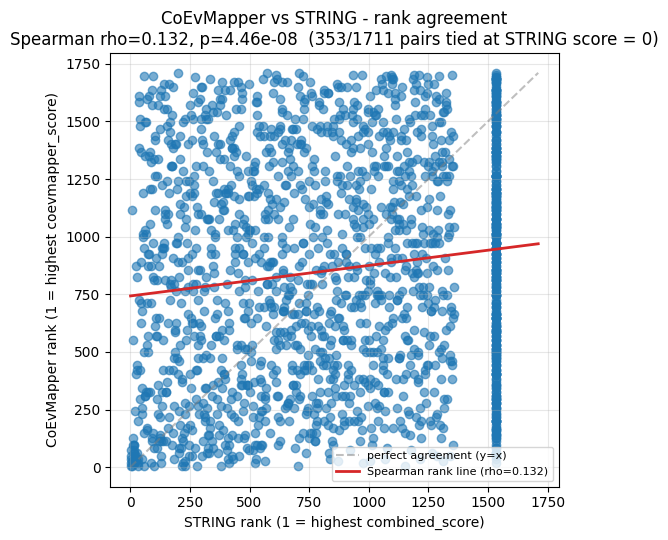

CoEvMapper edges (>= 0.3): 27   STRING edges (>= 0.6): 467   shared (same pair drawn in both networks): 18
Spearman rank correlation with STRING, by CoEvMapper score definition:


,coevmapper_score_variant,n_pairs,spearman_rho_full,spearman_p_full,n_nonzero_pairs,spearman_rho_nonzero,spearman_p_nonzero
0,"interaction_matrix (current default, self-normalized raw score)",1711,0.008,0.734,1358,0.036,0.187
1,weighted_matrix_scaled (self-normalized x contact-count weighted),1711,0.135,2.12e-08,1358,0.152,2.01e-08
2,"percentage_matrix (contact count, % of row/col max)",1711,0.179,7.94e-14,1358,0.182,1.41e-11
3,weighted_rank_norm (row/col rank consensus),1711,0.132,4.46e-08,1355,0.147,5.61e-08


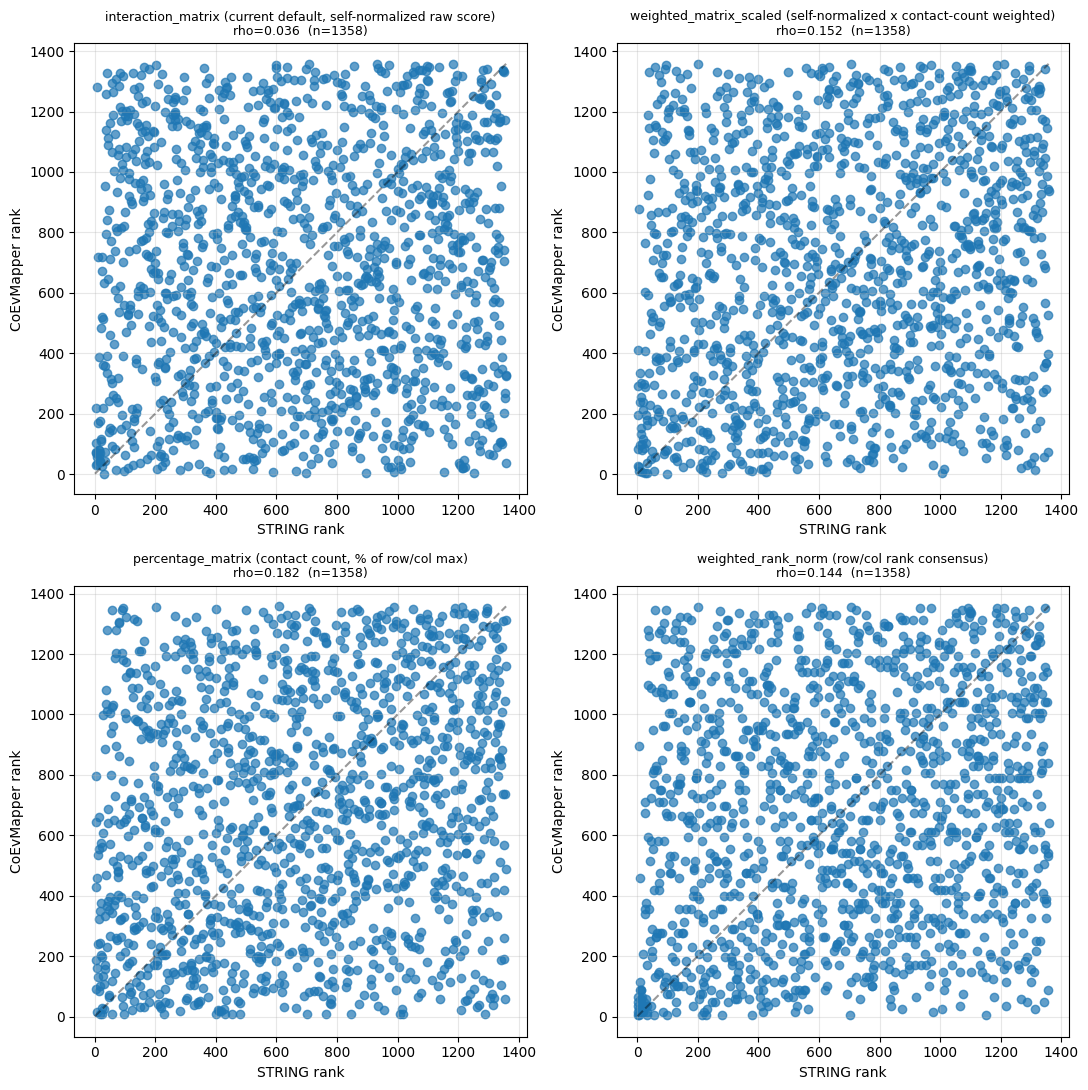

Overall precision (all 1711 pairs, STRING >= 0.95): 0.028
Best precision using CoEvMapper rank as a cutoff: 0.500 at top_n=4

Pearson r (raw scores), FULL set:        0.141  (p=4.9e-09)
Kendall's tau (rank agreement), FULL set: 0.091  (p=3.71e-08)
Pearson r (raw scores), NONZERO-only (1355 pairs):        0.161  (p=2.72e-09)
Kendall's tau (rank agreement), NONZERO-only (1355 pairs): 0.100  (p=4.59e-08)
ROC AUC: 0.775  (p=7.92e-11 vs 0.5, Mann-Whitney; 48 STRING-positive pairs, 1663 negative)


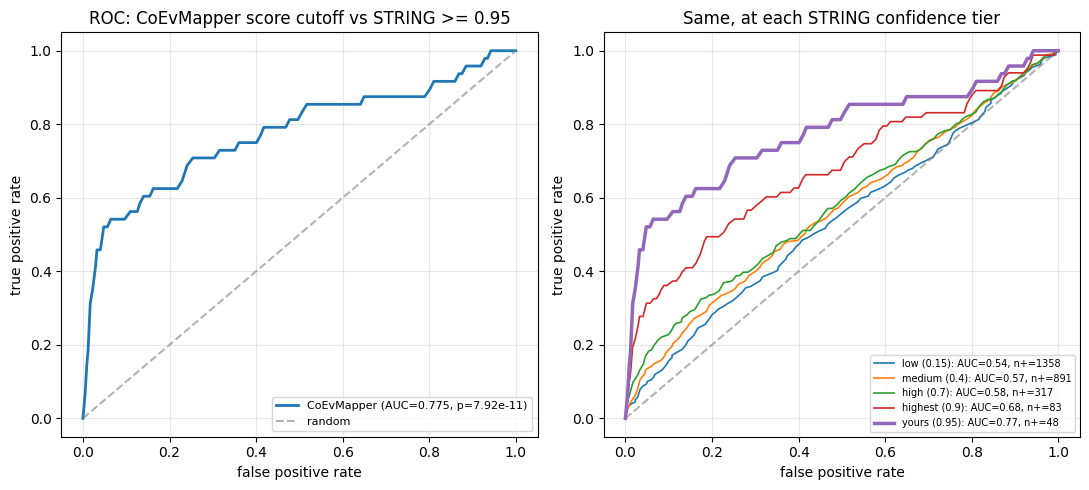

AUC of the CoEvMapper score at each STRING confidence tier:


,STRING threshold,positive pairs,negative pairs,AUC,p (vs 0.5)
0,low (0.15),1358,353,0.541,0.0169
1,medium (0.4),891,820,0.567,1.71e-06
2,high (0.7),317,1394,0.582,5.21e-06
3,highest (0.9),83,1628,0.676,5.75e-08
4,yours (0.95),48,1663,0.775,7.92e-11


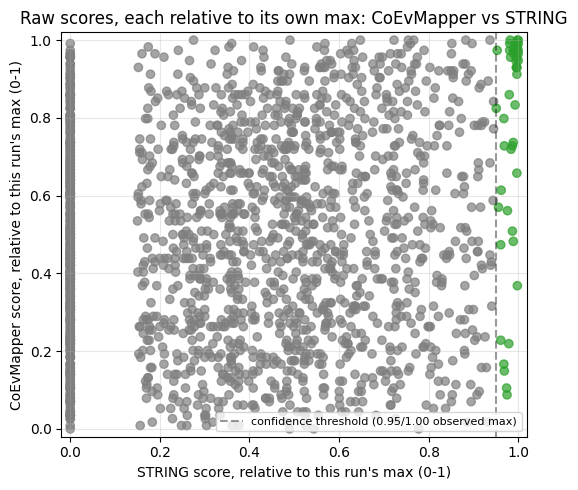

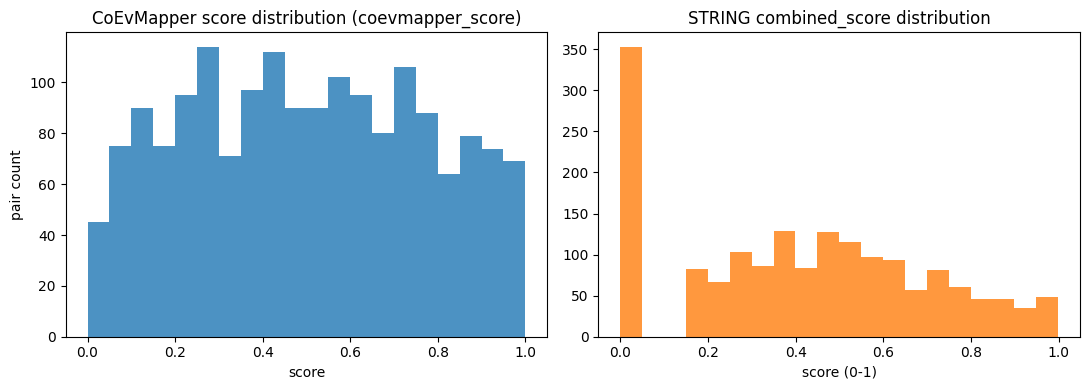


Most discordant pairs (biggest |coev_rank - string_rank|):


,protein_1,protein_2,coevmapper_score,coev_rank,string_score,string_rank,rank_diff
1694,224308.BSU17030,224308.BSU17700,0.017544,1697.0,0.932,58.5,1638.5
1695,224308.BSU17030,224308.BSU17670,0.017544,1697.0,0.886,94.0,1603.0
1604,224308.BSU11750,224308.BSU36050,0.087719,1608.5,0.974,37.0,1571.5
1634,224308.BSU11770,224308.BSU36050,0.070175,1637.5,0.894,89.5,1548.0
1580,224308.BSU11750,224308.BSU36070,0.105263,1583.5,0.973,38.0,1545.5
1608,224308.BSU17700,224308.BSU36060,0.087719,1608.5,0.907,79.5,1529.0
1593,224308.BSU17030,224308.BSU36070,0.096491,1596.5,0.912,70.5,1526.0
1661,224308.BSU17700,224308.BSU30900,0.052632,1661.5,0.837,141.0,1520.5
20,224308.BSU28110,224308.BSU37900,0.991228,17.0,0.000,1535.0,1518.0
1632,224308.BSU11770,224308.BSU17030,0.070175,1637.5,0.850,128.5,1509.0


,protein,coevmapper_degree,string_degree,degree_diff
0,224308.BSU11740,1,39,38
1,224308.BSU36050,0,34,34
2,224308.BSU17030,0,32,32
3,224308.BSU11750,1,32,31
4,224308.BSU36070,2,32,30
5,224308.BSU40530,0,30,30
6,224308.BSU11760,1,30,29
7,224308.BSU30900,2,30,28
8,224308.BSU12090,0,24,24
9,224308.BSU11770,1,24,23


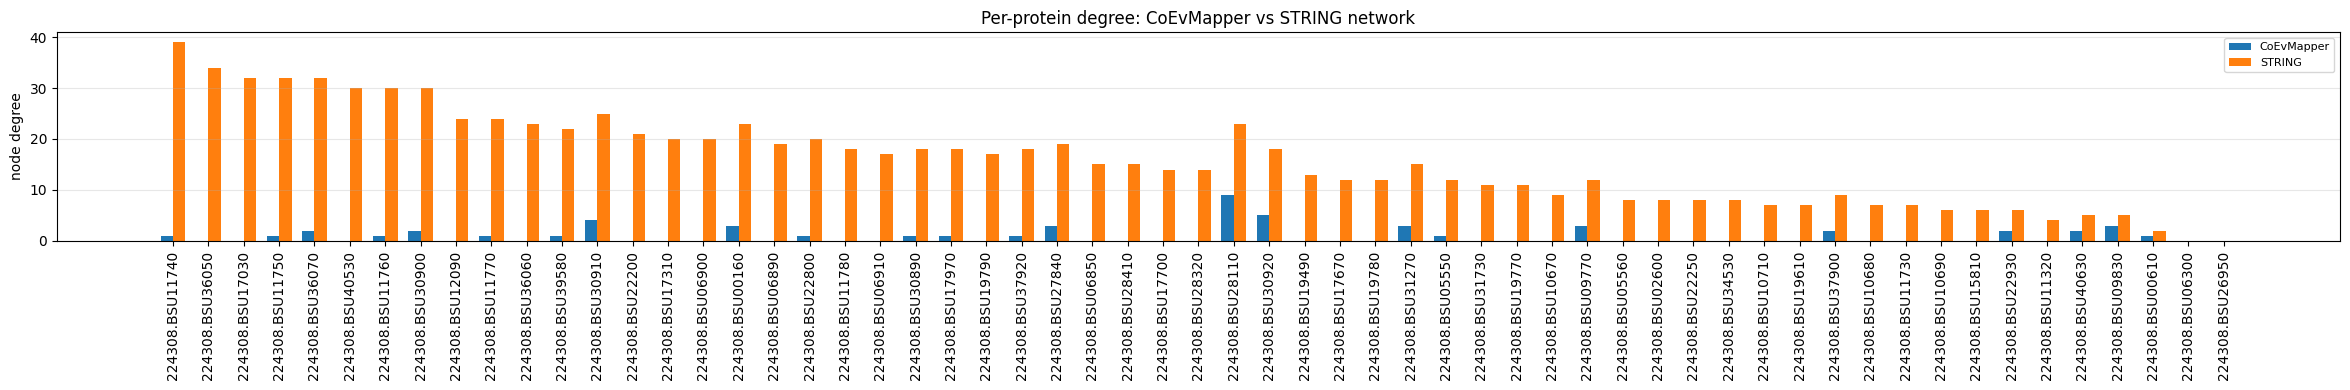


Summary - Spearman rho=0.144, Pearson r=0.141, Kendall tau=0.091, ROC AUC=0.775, overall precision=0.028


In [ ]:
# STEP 1: TRING mapping: resolve each input protein to species + STRING ID
#@markdown Maps every protein in this run to an NCBI taxon ID and a STRING identifier, so the
#@markdown CoEvMapper network can be checked against STRING's own interaction scores. STRING's
#@markdown public API only accepts names/accessions, not raw amino acid sequences, so each
#@markdown protein's own NCBI record is used to find the best STRING-friendly identifier
#@markdown (gene/locus tag first, then the accession itself, then the annotated product name).

import os
import re
import time
import requests
import pandas as pd
from io import StringIO
from collections import defaultdict
from Bio import Entrez, SeqIO

STRING_API = "https://string-db.org/api"
STRING_CALLER = "coevfold_coevmapper_stringcheck"  #@param {type:"string"}
NCBI_EMAIL = "chris.l.b.graham@warwick.ac.uk"  #@param {type:"string"}
STRING_MAPPING_CACHE = "string_mapping_cache.csv"

Entrez.email = NCBI_EMAIL


def clean_accession(accession):
    """Same header-cleaning logic as the "More info" annotation cell above, kept local here so
    this section works even if that cell has not been run in this session."""
    accession = str(accession).strip()
    if "|" in accession:
        parts = accession.split("|")
        for part in parts:
            if (part.startswith("WP_") or re.match(r"^[A-Z]{2}_\d+", part)
                    or re.match(r"^[A-Z]{1,5}\d+\.\d+$", part)):
                accession = part
                break
    return accession.split()[0]


# Rebuild the same (name, accession, sequence) triples "prep_inputs" produced, straight from the
# uploaded FASTA records still in memory - keeps this section independent of exactly which other
# cells have already run, and immune to the job-name simplification losing the real accession.
raw_triples = []
for record in records:
    seq = re.sub("[^A-Z:/()]", "", str(record.seq).upper())
    if not seq:
        continue
    raw_triples.append((simplify_header(record), clean_accession(record.id), seq))

print(f"Resolving species + STRING identifiers for {len(raw_triples)} proteins...")


def parse_string_native_id(accession):
    """If `accession` is already a STRING-native identifier - "<taxon_id>.<locus/protein id>",
    e.g. "224308.BSU24430" - return (taxon_id, string_id) directly, no NCBI/STRING lookup
    needed. This is exactly the header format you get when a FASTA is downloaded from STRING
    itself, so for FASTAs pulled from STRING every protein should hit this path and skip NCBI
    entirely (NCBI efetch fails on a STRING id since it isn't a GenBank/RefSeq accession, which
    is why every protein was previously reported as "could not determine organism/taxon").
    Returns None if `accession` doesn't look like a STRING id."""
    m = re.match(r"^(\d+)\.(\S+)$", accession)
    if m:
        return m.group(1), accession
    return None


def fetch_ncbi_organism_and_gene(accession):
    """One NCBI GenBank lookup -> {"taxon_id", "gene", "product"} or None on failure."""
    try:
        handle = Entrez.efetch(db="protein", id=accession, rettype="gb", retmode="text")
        data = handle.read()
        handle.close()
        rec = next(SeqIO.parse(StringIO(data), "genbank"), None)
        if rec is None:
            return None

        taxon_id = gene = product = None
        for feature in rec.features:
            if feature.type == "source":
                for xref in feature.qualifiers.get("db_xref", []):
                    if xref.startswith("taxon:"):
                        taxon_id = xref.split(":")[1]
            if feature.type in ("CDS", "Protein", "gene") and gene is None:
                gene = (feature.qualifiers.get("gene", [None])[0]
                        or feature.qualifiers.get("locus_tag", [None])[0])
            if feature.type == "Protein" and product is None:
                product = feature.qualifiers.get("product", [None])[0]
        if product is None:
            product = rec.description
        return {"taxon_id": taxon_id, "gene": gene, "product": product}
    except Exception as e:
        print(f"  NCBI lookup failed for {accession}: {e}")
        return None


def string_get_id(candidate, taxon_id):
    """One get_string_ids call for a SINGLE identifier -> (stringId, preferredName) or None.
    Only used for the NCBI fallback path below, where each protein's best candidate identifier
    is only known after its own NCBI lookup - there's nothing to batch there."""
    try:
        resp = requests.get(f"{STRING_API}/tsv/get_string_ids", params={
            "identifiers": candidate,
            "species": taxon_id,
            "limit": 1,
            "echo_query": 1,
            "caller_identity": STRING_CALLER,
        }, timeout=15)
        resp.raise_for_status()
        df = pd.read_csv(StringIO(resp.text), sep="\t")
        if len(df) == 0:
            return None
        return df.iloc[0]["stringId"], df.iloc[0]["preferredName"]
    except Exception as e:
        print(f"    STRING lookup failed for '{candidate}' (taxon {taxon_id}): {e}")
        return None


def string_get_ids_batch(candidates, taxon_id):
    """ONE get_string_ids call for MANY identifiers at once (STRING's own batch mode: identifiers
    separated by a carriage return, echo_query=1 so each returned row says which input it came
    from). STRING's docs write this separator as the literal text "%0d" because that's how you'd
    type it directly into a URL - but here `requests` does its own percent-encoding of the params
    dict, so passing the 3-character string "%0d" gets double-encoded into "%250d", which STRING
    doesn't recognize as a separator at all (it silently treats the whole blob as one malformed
    identifier). The fix is to join with an actual "\r" character and let `requests` encode it
    to %0D itself, exactly once. This is what actually lets the whole FASTA's id list go to STRING
    in a single request instead of one round trip per protein - the same batching the network cell
    below uses to rebuild the full STRING network for this protein set in one shot. Returns a
    DataFrame (possibly empty on failure) with a "queryItem" column to match rows back to inputs."""
    try:
        resp = requests.get(f"{STRING_API}/tsv/get_string_ids", params={
            "identifiers": "\r".join(candidates),
            "species": taxon_id,
            "limit": 1,
            "echo_query": 1,
            "caller_identity": STRING_CALLER,
        }, timeout=30)
        resp.raise_for_status()
        return pd.read_csv(StringIO(resp.text), sep="\t")
    except Exception as e:
        print(f"    batch STRING lookup failed for taxon {taxon_id} ({len(candidates)} ids): {e}")
        return pd.DataFrame()


# Load cache from previous runs so reruns don't re-hit NCBI/STRING for the same proteins.
if os.path.exists(STRING_MAPPING_CACHE):
    mapping_df = pd.read_csv(STRING_MAPPING_CACHE)
    mapping_cache = {row["name"]: row.to_dict() for _, row in mapping_df.iterrows()}
else:
    mapping_cache = {}

mapping_rows = []
still_needed = []  # (name, accession, seq) not already cached with a successful resolution
for name, accession, seq in raw_triples:
    cached = mapping_cache.get(name)
    # Only reuse a cached row if it actually resolved last time - a cached FAILURE (no
    # string_id, e.g. from before parse_string_native_id existed, or a transient API error)
    # always gets retried instead of being silently replayed forever.
    if cached is not None and pd.notna(cached.get("string_id")):
        mapping_rows.append(cached)
    else:
        still_needed.append((name, accession, seq))

# ------------------------------------------------------------------------------------------
# Fast, BATCHED path: split out every accession that's already a STRING-native id
# ("<taxon_id>.<locus>", exactly what you get from a FASTA downloaded straight from STRING
# itself) and resolve ALL of them for a given species in ONE get_string_ids call - rather than
# one NCBI+STRING round trip per protein. This is the direct STRING-side equivalent of the
# CoEvMapper network: the whole submitted protein list goes to STRING in a single request, and
# (together with the network cell below, which does the same batching) rebuilds the matching
# STRING network for this exact set of proteins in one shot instead of piecing it together
# protein by protein.
# ------------------------------------------------------------------------------------------
native_by_taxon = defaultdict(list)  # taxon_id -> [(name, accession, seq, string_id)]
non_native = []
for name, accession, seq in still_needed:
    native = parse_string_native_id(accession)
    if native is not None:
        taxon_id, string_id = native
        native_by_taxon[taxon_id].append((name, accession, seq, string_id))
    else:
        non_native.append((name, accession, seq))

for taxon_id, entries in native_by_taxon.items():
    string_ids = [e[3] for e in entries]
    print(f"  batch-resolving {len(string_ids)} STRING-native id(s) for taxon {taxon_id} "
          f"in a single request...")
    batch_df = string_get_ids_batch(string_ids, taxon_id)
    time.sleep(1)  # STRING etiquette: max 1 request/sec

    preferred_by_query = {}
    if len(batch_df) and "queryItem" in batch_df.columns:
        preferred_by_query = dict(zip(batch_df["queryItem"], batch_df["preferredName"]))
    elif len(batch_df):
        # older API responses may omit queryItem when every id resolved 1:1, in order
        preferred_by_query = dict(zip(string_ids, batch_df["preferredName"]))

    for name, accession, seq, string_id in entries:
        mapping_rows.append({
            "name": name, "accession": accession, "taxon_id": taxon_id, "gene": None,
            "product": None, "string_id": string_id,
            "string_preferred_name": preferred_by_query.get(string_id),
            "resolved_via": "already_string_id",
        })

# ------------------------------------------------------------------------------------------
# Fallback path, one protein at a time: only for accessions that are NOT already STRING-native
# ids, where species/gene has to come from that protein's own NCBI record first.
# ------------------------------------------------------------------------------------------
for name, accession, seq in non_native:
    print(f"  {name} ({accession}) ...")

    row = {"name": name, "accession": accession, "taxon_id": None, "gene": None,
           "product": None, "string_id": None, "string_preferred_name": None,
           "resolved_via": None}

    ncbi_info = fetch_ncbi_organism_and_gene(accession)
    time.sleep(0.34)  # NCBI etiquette: max ~3 requests/sec without an API key

    if ncbi_info is None or ncbi_info["taxon_id"] is None:
        print(f"    could not determine organism/taxon for {accession} - skipping STRING lookup")
        mapping_rows.append(row)
        continue

    row.update({"taxon_id": ncbi_info["taxon_id"], "gene": ncbi_info["gene"],
                "product": ncbi_info["product"]})

    # Try, in order: gene/locus tag (most STRING-friendly), the raw accession, then the
    # annotated product name - first one that resolves wins.
    candidates = [c for c in [ncbi_info["gene"], accession, ncbi_info["product"]] if c]
    for candidate in candidates:
        hit = string_get_id(candidate, ncbi_info["taxon_id"])
        time.sleep(1)  # STRING etiquette: max 1 request/sec
        if hit is not None:
            row["string_id"], row["string_preferred_name"] = hit
            row["resolved_via"] = candidate
            break

    if row["string_id"] is None:
        print(f"    no STRING match found for {name} (tried {candidates})")

    mapping_rows.append(row)

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(STRING_MAPPING_CACHE, index=False)

n_mapped = mapping_df["string_id"].notna().sum()
print(f"\n{n_mapped}/{len(mapping_df)} proteins resolved to a STRING identifier")
if n_mapped < len(mapping_df):
    unmapped = mapping_df[mapping_df["string_id"].isna()]["name"].tolist()
    print(f"Unmapped (no STRING entry found - check manually if these matter): {unmapped}")
display(mapping_df)


# STEP 2: etch STRING network scores for the mapped proteins
#@markdown Pulls every pairwise STRING combined_score among the proteins that resolved to a
#@markdown STRING identifier, grouped by species (STRING's network endpoint scores pairs within
#@markdown one organism at a time - cross-species pairs in a mixed input simply have no STRING
#@markdown comparison and are reported separately below rather than silently dropped).
#@markdown Note: the "score" column STRING actually returns from this endpoint is a 0-1 float
#@markdown (e.g. 0.923), NOT the 0-1000 integer scale STRING's website and the `required_score`
#@markdown INPUT filter parameter use - those are two different conventions in the same API.
#@markdown `required_score` is fixed at 0 below (not exposed as a param) so STRING is asked for
#@markdown every pair down to the lowest possible score - nothing is filtered out on the way in;
#@markdown any pair it still doesn't return is one it has zero recorded evidence for, and that
#@markdown genuine zero is filled in explicitly further down rather than left out of the
#@markdown comparison. `network_type` below chooses WHICH evidence counts as an "interaction" in
#@markdown the first place: "physical" keeps only evidence for direct physical binding
#@markdown (experiments + curated interaction databases), while "functional" (STRING's website
#@markdown default) also counts genomic neighborhood, gene fusion, co-occurrence, co-expression
#@markdown and text-mining - associations that can be real without the two proteins ever touching.
#@markdown Coevolution signal (what CoEvMapper measures) is a proxy for direct contact, so
#@markdown "physical" is the fairer thing to benchmark it against and is the default here.

import itertools
from collections import defaultdict

STRING_NETWORK_TYPE = "functional"  #@param ["physical", "functional"]

mapped_df = mapping_df[mapping_df["string_id"].notna()].copy()
string_scores = {}  # frozenset({name_i, name_j}) -> combined score (0-1 float, per the API)
species_groups = defaultdict(list)
for _, row in mapped_df.iterrows():
    species_groups[row["taxon_id"]].append(row)

print(f"{len(mapped_df)} proteins mapped, across {len(species_groups)} species group(s)")
print(f"STRING network_type = '{STRING_NETWORK_TYPE}'")

for taxon_id, rows in species_groups.items():
    if len(rows) < 2:
        print(f"  taxon {taxon_id}: only 1 mapped protein - no pairs to score, skipping")
        continue

    string_ids = [r["string_id"] for r in rows]
    id_to_name = {r["string_id"]: r["name"] for r in rows}

    print(f"  taxon {taxon_id}: querying STRING network for {len(string_ids)} proteins...")
    # Join with an actual carriage-return character, not the literal text "%0d" - `requests`
    # percent-encodes params itself, so a literal "%0d" gets double-encoded to "%250d", which
    # STRING doesn't recognize as a separator (this was silently mangling every batched request,
    # which is why STRING combined_scores were coming back near-zero for nearly every pair).
    resp = requests.get(f"{STRING_API}/tsv/network", params={
        "identifiers": "\r".join(string_ids),
        "species": taxon_id,
        "required_score": 0,  # ask for every pair down to the floor - nothing pre-filtered here
        "network_type": STRING_NETWORK_TYPE,
        "caller_identity": STRING_CALLER,
    }, timeout=30)
    time.sleep(1)

    try:
        resp.raise_for_status()
        net_df = pd.read_csv(StringIO(resp.text), sep="\t")
    except Exception as e:
        print(f"    STRING network fetch failed for taxon {taxon_id}: {e}")
        continue

    for _, edge in net_df.iterrows():
        name_a = id_to_name.get(edge["stringId_A"])
        name_b = id_to_name.get(edge["stringId_B"])
        if name_a and name_b and name_a != name_b:
            string_scores[frozenset({name_a, name_b})] = float(edge["score"])

# Every same-species pair among mapped proteins that STRING returned no row for genuinely has no
# recorded evidence at all under this network_type - that's a real 0, not a gap, so it's filled
# in explicitly here (this is what guarantees low/zero-scoring pairs stay IN the comparison below,
# rather than only the pairs STRING happened to return a row for).
n_pairs_seen = len(string_scores)
for rows in species_groups.values():
    if len(rows) < 2:
        continue
    for r1, r2 in itertools.combinations(rows, 2):
        pair = frozenset({r1["name"], r2["name"]})
        string_scores.setdefault(pair, 0.0)

n_zero_filled = len(string_scores) - n_pairs_seen
n_nonzero = sum(1 for v in string_scores.values() if v > 0)
print(f"\n{len(string_scores)} same-species pairs covered in total "
      f"({n_pairs_seen} returned by STRING with a real score, {n_zero_filled} had no STRING "
      f"evidence at all and were filled in as 0.0)")
print(f"Of those, {n_nonzero} have a nonzero combined score and "
      f"{len(string_scores) - n_nonzero} are exact zeros - both kinds are kept for the "
      f"correlation/plots below, nothing is dropped for being low or zero.")


# STEP 3: oEvMapper vs STRING: rank correlation
#@markdown Compares every gene pair CoEvMapper scored against STRING's combined_score for the
#@markdown same pair. Because the two scores live on completely different scales (STRING's
#@markdown combined_score is dominated by many exact zeros plus a skewed tail; CoEvMapper's
#@markdown score is a continuous coevolution signal), the comparison is done by RANK
#@markdown (Spearman), not raw magnitude - do the two methods agree on which pairs are most
#@markdown likely to interact, not on the exact numbers. The STRING confidence threshold below is
#@markdown kept only as a secondary annotation (coloring points/edges), not the primary metric.
#@markdown `COEVMAPPER_SCORE_SOURCE` picks which of the CoEvMapper score definitions from the
#@markdown heatmap cell earlier in this notebook is used as `coevmapper_score` everywhere below
#@markdown (the sensitivity-check cell further down runs all four side by side regardless of this
#@markdown choice - this dropdown just fixes which one the main analysis, plots, and extra
#@markdown outputs use): `interaction_matrix` is each pair's raw GREMLIN score self-normalized
#@markdown against that protein's own score (self = 1); `weighted_matrix_scaled` multiplies that
#@markdown by how often the pair co-occurs (contact count, relative to the row/column max), then
#@markdown scales the result to this run's own max; `percentage_matrix` is just that contact-count
#@markdown term on its own (0-100%, converted to 0-1 here); `weighted_rank_norm` ignores magnitude
#@markdown entirely and uses each pair's row/column rank position instead (1 = strongest, 0 =
#@markdown weakest).

from scipy.stats import spearmanr

STRING_CONFIDENCE_THRESHOLD = 0.95  #@param {type:"number"}

COEVMAPPER_SCORE_SOURCE = "weighted_rank_norm (row/col rank consensus)"  #@param ["interaction_matrix (self-normalized raw score)", "weighted_matrix_scaled (self-normalized x contact-count weighted)", "percentage_matrix (contact count, % of row/col max)", "weighted_rank_norm (row/col rank consensus)"]

_coevmapper_score_sources = {
    "interaction_matrix (self-normalized raw score)": interaction_matrix,
    "weighted_matrix_scaled (self-normalized x contact-count weighted)": weighted_matrix_scaled,
    "percentage_matrix (contact count, % of row/col max)": percentage_matrix / 100.0,
    "weighted_rank_norm (row/col rank consensus)": weighted_rank_norm,
}
COEVMAPPER_SCORE_MATRIX = _coevmapper_score_sources[COEVMAPPER_SCORE_SOURCE]
print(f"Using CoEvMapper score source: {COEVMAPPER_SCORE_SOURCE}")

comparison_rows = []
skipped_no_string = skipped_cross_species = 0
taxon_by_name = {row["name"]: row["taxon_id"] for _, row in mapped_df.iterrows()}

if len(taxon_by_name) == 0:
    print("WARNING: mapped_df has 0 proteins with a STRING id, so every pair below will be "
          "skipped and comparison_df will come out empty. This almost always means the mapping "
          "and/or network cell above ran with a STALE mapping_df in THIS kernel session (e.g. "
          "you pasted in fixed code but haven't actually re-run mapping -> network -> this cell, "
          "in that order, since). Re-run those two cells first, confirm mapping prints "
          "'N/N proteins resolved' with N > 0, then re-run this cell.")

for name_i, name_j in itertools.combinations(COEVMAPPER_SCORE_MATRIX.index, 2):
    coev_score = COEVMAPPER_SCORE_MATRIX.loc[name_i, name_j]
    pair = frozenset({name_i, name_j})

    if name_i not in taxon_by_name or name_j not in taxon_by_name:
        skipped_no_string += 1
        continue
    if taxon_by_name[name_i] != taxon_by_name[name_j]:
        skipped_cross_species += 1
        continue

    string_score = string_scores.get(pair, 0.0)
    comparison_rows.append({
        "protein_1": name_i, "protein_2": name_j,
        "coevmapper_score": coev_score, "string_score": string_score,
        "string_high_confidence": string_score >= STRING_CONFIDENCE_THRESHOLD,
    })

# Build with an explicit column list so an empty result (0 comparable pairs) still has every
# column downstream cells expect, instead of a bare 0x0 DataFrame that KeyErrors on first use.
comparison_df = pd.DataFrame(comparison_rows, columns=[
    "protein_1", "protein_2", "coevmapper_score", "string_score", "string_high_confidence"])
if len(comparison_df) > 0:
    comparison_df["coev_rank"] = comparison_df["coevmapper_score"].rank(ascending=False, method="average")
    comparison_df["string_rank"] = comparison_df["string_score"].rank(ascending=False, method="average")
    comparison_df["rank_diff"] = (comparison_df["coev_rank"] - comparison_df["string_rank"]).abs()
    comparison_df = comparison_df.sort_values("coev_rank").reset_index(drop=True)
else:
    for col in ("coev_rank", "string_rank", "rank_diff"):
        comparison_df[col] = pd.Series(dtype=float)
comparison_df.to_csv("coevmapper_vs_string.csv", index=False)

print(f"{len(comparison_df)} gene pairs compared "
      f"({skipped_no_string} skipped - unmapped to STRING, "
      f"{skipped_cross_species} skipped - cross-species)")

if len(comparison_df) >= 3:
    rho, pval = spearmanr(comparison_df["coevmapper_score"], comparison_df["string_score"])
    print(f"\nSpearman rank correlation, FULL set ({len(comparison_df)} pairs, zeros included "
          f"on both sides): rho={rho:.3f}, p={pval:.3g}")
else:
    rho = pval = float("nan")
    print("\nToo few comparable pairs for a meaningful correlation (need at least 3).")

# Zeros here are real signal, not a scaling artifact. interaction_matrix self-normalizes each
# row by that protein's own self-score (score / self-score), which rescales magnitude but can't
# turn a genuine 0 pairwise GREMLIN score into anything but 0 - so a 0 here still means "no
# coupling signal detected" for that pair, same as it would for any of the other score variants.
# A 0 STRING score is likewise genuine "no evidence" (see the network cell above). So the
# full-set rho
# above is a legitimate number: it credits the two methods for agreeing on the (usually large)
# set of non-interacting pairs, same as it credits them for agreeing on the interacting ones.
# It also means that agreement on the bulk of true negatives can dominate rho even when the two
# methods disagree on ranking among the pairs that actually look interesting - which is a
# different, complementary question. This second number answers that one: same correlation,
# restricted to pairs where BOTH methods reported a nonzero score.
nonzero_mask = (comparison_df["coevmapper_score"] > 0) & (comparison_df["string_score"] > 0)
comparison_nonzero = comparison_df[nonzero_mask]
n_dropped = len(comparison_df) - len(comparison_nonzero)
if len(comparison_nonzero) >= 3:
    rho_nz, pval_nz = spearmanr(comparison_nonzero["coevmapper_score"],
                                 comparison_nonzero["string_score"])
    print(f"Spearman rank correlation, NONZERO-only ({len(comparison_nonzero)} pairs, "
          f"{n_dropped} dropped where either score was exactly 0): "
          f"rho={rho_nz:.3f}, p={pval_nz:.3g}")
else:
    rho_nz = pval_nz = float("nan")
    print(f"Spearman rank correlation, NONZERO-only: too few pairs with a nonzero score on both "
          f"sides ({len(comparison_nonzero)}, need at least 3) to compute.")

# Rank-order agreement at the top, without needing any confidence threshold: of CoEvMapper's
# top 5 predicted pairs, how many are also in STRING's own top 5 by combined_score?
top_n = min(5, len(comparison_df))
if top_n > 0:
    top_coev_pairs = {frozenset(p) for p in zip(
        comparison_df.nsmallest(top_n, "coev_rank")["protein_1"],
        comparison_df.nsmallest(top_n, "coev_rank")["protein_2"])}
    top_string_pairs = {frozenset(p) for p in zip(
        comparison_df.nsmallest(top_n, "string_rank")["protein_1"],
        comparison_df.nsmallest(top_n, "string_rank")["protein_2"])}
    overlap = top_coev_pairs & top_string_pairs
    print(f"Top {top_n} overlap: {len(overlap)}/{top_n} of CoEvMapper's top-ranked pairs are "
          f"also in STRING's top {top_n} by combined_score")

display(comparison_df)


# STEP 4: ank-vs-rank scatter, plus the STRING network rebuilt and shown side-by-side
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import spearmanr

# Full set, zero-STRING pairs included - the same population as the FULL Spearman rho printed
# in the correlation cell above. Note the pairs with a STRING score of exactly 0 are genuinely
# tied (see the network cell), so `rank(method="average")` gives them all the same coev_rank and
# string_rank value; on the chart that shows up as points stacked in a vertical line at one x
# position. That's a real feature of the data (STRING has no evidence at all for that many
# pairs), not a plotting bug - it's called out in the title below rather than hidden by excluding
# those pairs.
n_string_zero = int((comparison_df["string_score"] == 0).sum())

if len(comparison_df) >= 3:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(comparison_df["string_rank"], comparison_df["coev_rank"],
               color="tab:blue", alpha=0.6)
    max_rank = len(comparison_df)
    ax.plot([1, max_rank], [1, max_rank], "--", color="gray", alpha=0.5,
            label="perfect agreement (y=x)")

    # The Spearman rank line: a least-squares straight line fit through these same rank values -
    # Spearman's rho IS just Pearson's r computed on ranks, so this line is the direct visual
    # counterpart of the rho printed in the title (steeper/flatter = weaker agreement, its tilt
    # toward the y=x line above = stronger agreement).
    slope, intercept = np.polyfit(comparison_df["string_rank"], comparison_df["coev_rank"], 1)
    x_fit = np.array([1, max_rank])
    ax.plot(x_fit, slope * x_fit + intercept, color="tab:red", linewidth=2,
            label=f"Spearman rank line (rho={rho:.3f})")

    ax.set_xlabel("STRING rank (1 = highest combined_score)")
    ax.set_ylabel("CoEvMapper rank (1 = highest coevmapper_score)")
    ax.set_title(f"CoEvMapper vs STRING - rank agreement\nSpearman rho={rho:.3f}, p={pval:.3g}  "
                 f"({n_string_zero}/{len(comparison_df)} pairs tied at STRING score = 0)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("coevmapper_vs_string_rank_scatter.png", dpi=150)
    plt.show()
else:
    print("Skipping rank scatter - too few comparable pairs.")

# ------------------------------------------------------------------------------------------
# Rebuild the STRING network as its OWN graph (not just an annotation on the CoEvMapper graph)
# so the two networks can be looked at side by side on identical node positions - a direct
# "does STRING draw the same picture as CoEvMapper, or a different one" visual comparison,
# on top of the rank correlation above.
# ------------------------------------------------------------------------------------------
# Its own CoEvMapper-side edge-score minimum, separate from whatever `MIN_EDGE_SCORE` the
# earlier "existing min edge score coevmapper map" cell happens to have last set - this way the
# STRING comparison's CoEvMapper panel doesn't silently change depending on which other cell you
# ran most recently, and you can tune the two sides of this specific comparison independently
# (mirrors STRING_MIN_EDGE_SCORE below).
COEVMAPPER_MIN_EDGE_SCORE = 0.3  #@param {type:"number"}
STRING_MIN_EDGE_SCORE = 0.6  #@param {type:"number"}

all_names = sorted(set(weighted_matrix_scaled.index) | set(weighted_matrix_scaled.columns))

# Display name for each protein on the network diagram below. `name` (the identifier used
# everywhere else in this notebook, including as the graph's actual node keys) is whatever the
# FASTA header gave CoEvMapper - for a FASTA pulled straight from STRING that's the STRING-native
# id ("224308.BSU24430"), which is exact but unreadable on a chart. STRING's own preferred_name
# (already fetched in the mapping cell) is normally a short, human gene symbol, so it's used as
# the label wherever available; the NCBI-fallback path's own gene symbol is the next best thing;
# anything with neither (STRING lookup failed) just falls back to showing its raw name as-is.
import pandas as pd

common_name = {}
for _, row in mapping_df.iterrows():
    if pd.notna(row.get("string_preferred_name")):
        common_name[row["name"]] = row["string_preferred_name"]
    elif pd.notna(row.get("gene")):
        common_name[row["name"]] = row["gene"]
for name in all_names:
    common_name.setdefault(name, name)

edges_long = (
    interaction_df.reset_index()
    .melt(id_vars=interaction_df.index.name, var_name="protein2", value_name="score")
    .rename(columns={interaction_df.index.name: "protein1"})
)
edges_long = edges_long[(edges_long["protein1"] != edges_long["protein2"]) & (edges_long["score"] > 0)]

G_coev = nx.Graph()
G_coev.add_nodes_from(all_names)
for _, row in edges_long.iterrows():
    if row["score"] >= COEVMAPPER_MIN_EDGE_SCORE:
        pair = frozenset({row["protein1"], row["protein2"]})
        G_coev.add_edge(row["protein1"], row["protein2"], weight=row["score"],
                         string_score=string_scores.get(pair))

# the STRING network, built directly from string_scores - completely independent of the
# CoEvMapper edges, so any agreement between the two panels below is real, not shared code
G_string = nx.Graph()
G_string.add_nodes_from(all_names)
for pair, score in string_scores.items():
    if score >= STRING_MIN_EDGE_SCORE:
        a, b = tuple(pair)
        G_string.add_edge(a, b, weight=score, string_score=score)

# one shared layout, from the union of both graphs' edges, so node positions match across both
# panels - the whole point of drawing them side by side rather than as two unrelated figures
pos = nx.spring_layout(nx.compose(G_coev, G_string), k=0.35, weight="weight",
                        iterations=200, seed=42)


def _network_traces(G, edge_color_fn, hover_fn):
    edge_traces = []
    for u, v, d in G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_traces.append(go.Scatter(
            x=[x0, x1, None], y=[y0, y1, None],
            line=dict(width=max(d["weight"], 0.05) * EDGE_WIDTH_SCALE, color=edge_color_fn(d)),
            hoverinfo="text", text=hover_fn(u, v, d), mode="lines", showlegend=False))
    node_x = [pos[n][0] for n in G.nodes()]
    node_y = [pos[n][1] for n in G.nodes()]
    node_trace = go.Scatter(x=node_x, y=node_y, mode="markers+text",
                             marker=dict(size=20, color="steelblue", line=dict(width=1, color="black")),
                             text=[common_name.get(n, n) for n in G.nodes()],
                             hovertext=[f"{common_name.get(n, n)}<br>{n}" for n in G.nodes()],
                             textposition="top center", hoverinfo="text", showlegend=False)
    return edge_traces + [node_trace]


coev_traces = _network_traces(
    G_coev,
    edge_color_fn=lambda d: ("seagreen" if (d["string_score"] is not None
                                             and d["string_score"] >= STRING_CONFIDENCE_THRESHOLD)
                              else "#bbb"),
    hover_fn=lambda u, v, d: (f"{common_name.get(u, u)}-{common_name.get(v, v)}: "
                              f"CoEvMapper={d['weight']:.2f}, STRING={d['string_score']}"),
)
string_traces = _network_traces(
    G_string,
    edge_color_fn=lambda d: ("seagreen" if d["string_score"] >= STRING_CONFIDENCE_THRESHOLD
                              else "#888"),
    hover_fn=lambda u, v, d: (f"{common_name.get(u, u)}-{common_name.get(v, v)}: "
                              f"STRING={d['string_score']:.2f}"),
)

fig = make_subplots(rows=1, cols=2, subplot_titles=(
    f"CoEvMapper network (green = STRING-confirmed >={STRING_CONFIDENCE_THRESHOLD})",
    f"STRING network, rebuilt from the same proteins (score >= {STRING_MIN_EDGE_SCORE})"))
for trace in coev_traces:
    fig.add_trace(trace, row=1, col=1)
for trace in string_traces:
    fig.add_trace(trace, row=1, col=2)
fig.update_layout(hovermode="closest", height=550, margin=dict(b=20, l=5, r=5, t=60))
fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False)
fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False)
fig.show()

n_coev_edges = G_coev.number_of_edges()
n_string_edges = G_string.number_of_edges()
n_shared_edges = sum(1 for u, v in G_coev.edges() if G_string.has_edge(u, v))
print(f"CoEvMapper edges (>= {COEVMAPPER_MIN_EDGE_SCORE}): {n_coev_edges}   "
      f"STRING edges (>= {STRING_MIN_EDGE_SCORE}): {n_string_edges}   "
      f"shared (same pair drawn in both networks): {n_shared_edges}")


# STEP 5: ensitivity check: rank agreement using CoEvMapper's other score variants
#@markdown The pipeline above computes several different CoEvMapper-side scores for the same gene
#@markdown pairs (the "Normalized Interaction Score" / "Relative Abundance" / "Weighted
#@markdown Interaction Score" heatmaps earlier in this notebook, plus the rank-consensus one after
#@markdown them): `interaction_matrix` (self-normalized raw GREMLIN score), `percentage_matrix`
#@markdown (contact count relative to the row/column max), `weighted_matrix_scaled` (the product
#@markdown of the two), and `weighted_rank_norm` (a row/column rank consensus, 1 = strongest
#@markdown pair). The correlation cell above picks ONE of these (via its `COEVMAPPER_SCORE_SOURCE`
#@markdown dropdown) for `coevmapper_score` and everything downstream of it; this cell instead
#@markdown reruns the same STRING comparison against ALL FOUR regardless of that dropdown, so you
#@markdown can see whether agreement with STRING holds up across every definition or is specific
#@markdown to whichever one is currently selected.

import itertools
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

score_variants = {
    "interaction_matrix (current default, self-normalized raw score)": interaction_matrix,
    "weighted_matrix_scaled (self-normalized x contact-count weighted)": weighted_matrix_scaled,
    "percentage_matrix (contact count, % of row/col max)": percentage_matrix / 100.0,
    "weighted_rank_norm (row/col rank consensus)": weighted_rank_norm,
}


def _paired_scores(score_matrix, require_nonzero_string):
    """Same pair-selection logic as the main correlation cell (same-species mapped pairs only),
    generalized to any of the score matrices above."""
    rows = []
    for name_i, name_j in itertools.combinations(weighted_matrix_scaled.index, 2):
        if name_i not in taxon_by_name or name_j not in taxon_by_name:
            continue
        if taxon_by_name[name_i] != taxon_by_name[name_j]:
            continue
        if name_i not in score_matrix.index or name_j not in score_matrix.columns:
            continue
        coev_val = score_matrix.loc[name_i, name_j]
        if pd.isna(coev_val):
            continue
        pair = frozenset({name_i, name_j})
        string_score = string_scores.get(pair, 0.0)
        if require_nonzero_string and string_score <= 0:
            continue
        rows.append({"coev_score": float(coev_val), "string_score": string_score})
    return pd.DataFrame(rows)


multiscore_summary = []
for score_name, score_matrix in score_variants.items():
    df_full = _paired_scores(score_matrix, require_nonzero_string=False)
    n_pairs = len(df_full)
    if n_pairs >= 3:
        rho_full, p_full = spearmanr(df_full["coev_score"], df_full["string_score"])
    else:
        rho_full = p_full = float("nan")

    df_nz = df_full[(df_full["coev_score"] > 0) & (df_full["string_score"] > 0)] if n_pairs else df_full
    if len(df_nz) >= 3:
        rho_nz, p_nz = spearmanr(df_nz["coev_score"], df_nz["string_score"])
    else:
        rho_nz = p_nz = float("nan")

    multiscore_summary.append({
        "coevmapper_score_variant": score_name, "n_pairs": n_pairs,
        "spearman_rho_full": rho_full, "spearman_p_full": p_full,
        "n_nonzero_pairs": len(df_nz), "spearman_rho_nonzero": rho_nz, "spearman_p_nonzero": p_nz,
    })

multiscore_df = pd.DataFrame(multiscore_summary)
multiscore_df.to_csv("coevmapper_vs_string_by_score_variant.csv", index=False)
print("Spearman rank correlation with STRING, by CoEvMapper score definition:")
# Format just for display (the CSV and multiscore_df itself keep full float precision) - pandas'
# default float display rounds to 6 decimal places, which shows a very small but nonzero p-value
# as a misleading 0.000000; .3g switches to scientific notation for anything that small instead.
display(multiscore_df.style.format({
    "spearman_rho_full": "{:.3f}".format, "spearman_p_full": "{:.3g}".format,
    "spearman_rho_nonzero": "{:.3f}".format, "spearman_p_nonzero": "{:.3g}".format,
}))

# One rank-scatter panel per score variant, using the same STRING-zero-excluded pairs and
# per-variant rank recomputation as the main rank scatter above, so the four panels are a fair
# comparison against each other.
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, (score_name, score_matrix) in zip(axes.flat, score_variants.items()):
    df_plot = _paired_scores(score_matrix, require_nonzero_string=True)
    if len(df_plot) >= 3:
        df_plot = df_plot.copy()
        df_plot["coev_rank"] = df_plot["coev_score"].rank(ascending=False, method="average")
        df_plot["string_rank"] = df_plot["string_score"].rank(ascending=False, method="average")
        rho, _ = spearmanr(df_plot["coev_score"], df_plot["string_score"])
        ax.scatter(df_plot["string_rank"], df_plot["coev_rank"], alpha=0.7, color="tab:blue")
        max_rank = len(df_plot)
        ax.plot([1, max_rank], [1, max_rank], "--", color="black", alpha=0.4)
        ax.set_title(f"{score_name}\nrho={rho:.3f}  (n={len(df_plot)})", fontsize=9)
    else:
        ax.set_title(f"{score_name}\ntoo few nonzero-STRING pairs (n={len(df_plot)})", fontsize=9)
    ax.set_xlabel("STRING rank")
    ax.set_ylabel("CoEvMapper rank")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("coevmapper_vs_string_score_variants.png", dpi=150)
plt.show()


# STEP 6: xtra outputs: precision-by-rank, raw-score scatter, distributions, ROC/AUC, and outliers
#@markdown Everything below is derived from `comparison_df` (built in the correlation cell) and
#@markdown `G_coev`/`G_string` (built in the network-plot cell above) - no new API calls, just
#@markdown squeezing more views out of the data already pulled.

import numpy as np
from scipy.stats import pearsonr, kendalltau

# Defensive: add the rank columns here if they're not already on comparison_df (e.g. the
# correlation cell above was run before they existed, or this kernel still has an older
# comparison_df from an earlier session) - this cell shouldn't fail just because of cell order.
ranked = comparison_df.copy()
if "coev_rank" not in ranked.columns:
    ranked["coev_rank"] = ranked["coevmapper_score"].rank(ascending=False, method="average")
if "string_rank" not in ranked.columns:
    ranked["string_rank"] = ranked["string_score"].rank(ascending=False, method="average")
if "rank_diff" not in ranked.columns:
    ranked["rank_diff"] = (ranked["coev_rank"] - ranked["string_rank"]).abs()
ranked = ranked.sort_values("coev_rank").reset_index(drop=True)

# ------------------------------------------------------------------------------------------
# 1. Precision @ top-N (by CoEvMapper rank) - of CoEvMapper's top N ranked pairs, what fraction
#    are STRING-confirmed (score >= STRING_CONFIDENCE_THRESHOLD)? Exactly the same idea as the
#    PDB-benchmark notebook's Top-L/5 precision, except the ground truth here is STRING evidence
#    instead of a real 3D contact, and the ranking source is CoEvMapper's weighted score.
# ------------------------------------------------------------------------------------------
hits = ranked["string_high_confidence"].astype(int).to_numpy()
top_ns = np.arange(1, len(ranked) + 1)
cum_hits = np.cumsum(hits)
precision_at_n = np.divide(cum_hits, top_ns, out=np.full_like(cum_hits, np.nan, dtype=float),
                            where=top_ns > 0)

precision_at_n_df = pd.DataFrame({"top_n": top_ns, "precision": precision_at_n,
                                   "cumulative_hits": cum_hits})
precision_at_n_df.to_csv("coevmapper_precision_at_n.csv", index=False)

overall_precision = hits.mean() if len(hits) else float("nan")
print(f"Overall precision (all {len(ranked)} pairs, STRING >= {STRING_CONFIDENCE_THRESHOLD}): "
      f"{overall_precision:.3f}")
if len(precision_at_n):
    best_idx = int(np.nanargmax(precision_at_n))
    print(f"Best precision using CoEvMapper rank as a cutoff: {precision_at_n[best_idx]:.3f} "
          f"at top_n={top_ns[best_idx]}")

# ------------------------------------------------------------------------------------------
# 2. Correlation summary - Spearman is already reported above; add Pearson (raw magnitude, for
#    completeness even though the scales differ) and Kendall's tau (another rank-agreement
#    measure, more robust to the many tied STRING zero-scores than Spearman).
# ------------------------------------------------------------------------------------------
if len(comparison_df) >= 3:
    pearson_r, pearson_p = pearsonr(comparison_df["coevmapper_score"], comparison_df["string_score"])
    kendall_tau, kendall_p = kendalltau(comparison_df["coevmapper_score"], comparison_df["string_score"])
    print(f"\nPearson r (raw scores), FULL set:        {pearson_r:.3f}  (p={pearson_p:.3g})")
    print(f"Kendall's tau (rank agreement), FULL set: {kendall_tau:.3f}  (p={kendall_p:.3g})")
else:
    pearson_r = pearson_p = kendall_tau = kendall_p = float("nan")

# Same FULL-vs-NONZERO-only split as the Spearman number in the correlation cell above, for
# consistency - see that cell for why zeros are kept in the FULL numbers by default.
nonzero_mask = (comparison_df["coevmapper_score"] > 0) & (comparison_df["string_score"] > 0)
comparison_nonzero = comparison_df[nonzero_mask]
if len(comparison_nonzero) >= 3:
    pearson_r_nz, pearson_p_nz = pearsonr(comparison_nonzero["coevmapper_score"],
                                           comparison_nonzero["string_score"])
    kendall_tau_nz, kendall_p_nz = kendalltau(comparison_nonzero["coevmapper_score"],
                                               comparison_nonzero["string_score"])
    print(f"Pearson r (raw scores), NONZERO-only ({len(comparison_nonzero)} pairs):        "
          f"{pearson_r_nz:.3f}  (p={pearson_p_nz:.3g})")
    print(f"Kendall's tau (rank agreement), NONZERO-only ({len(comparison_nonzero)} pairs): "
          f"{kendall_tau_nz:.3f}  (p={kendall_p_nz:.3g})")
else:
    pearson_r_nz = pearson_p_nz = kendall_tau_nz = kendall_p_nz = float("nan")
    print(f"Pearson/Kendall NONZERO-only: too few pairs with a nonzero score on both sides "
          f"({len(comparison_nonzero)}, need at least 3) to compute.")

# ------------------------------------------------------------------------------------------
# 3. ROC / AUC - CoEvMapper's own AUC. Each point on the curve is one CoEvMapper score cutoff
#    (every pair at or above it is called "interacting"), swept from the strictest cutoff
#    (bottom-left) to the loosest (top-right); each call is checked against STRING, which only
#    supplies the yes/no ground truth (STRING score >= the threshold). So the thresholding IS on
#    the coevolution score - STRING is just the answer key.
#    Pairs with tied CoEvMapper scores are treated as ONE cutoff step (a diagonal segment) rather
#    than in arbitrary order, which can otherwise push the AUC up or down - this matters for the
#    rank-based score especially. With ties handled this way the AUC is exactly the probability
#    that a random STRING-confirmed pair outscores a random unconfirmed one (ties count half),
#    i.e. the Mann-Whitney U statistic, which also gives a p-value against 0.5 (= random).
#    AUC < 0.5 is not the curve computed backwards: it means STRING-confirmed pairs really do sit
#    lower in CoEvMapper's ranking than unconfirmed ones at that STRING threshold.
# ------------------------------------------------------------------------------------------
from scipy.stats import mannwhitneyu


def _roc_curve(scores, labels):
    """Tie-aware ROC: one point per distinct CoEvMapper score, highest first."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=bool)
    n_p, n_n = int(labels.sum()), int((~labels).sum())
    tpr, fpr = [0.0], [0.0]
    for thr in np.unique(scores)[::-1]:
        called = scores >= thr
        tpr.append((called & labels).sum() / n_p)
        fpr.append((called & ~labels).sum() / n_n)
    tpr, fpr = np.array(tpr), np.array(fpr)
    # trapezoidal area by hand (np.trapz was removed in NumPy 2.0)
    return fpr, tpr, float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))


def _auc_and_p(scores, labels):
    """AUC as P(confirmed pair outscores unconfirmed pair), ties = 1/2, plus Mann-Whitney p."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=bool)
    pos, neg = scores[labels], scores[~labels]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan"), float("nan"), len(pos), len(neg)
    diff = pos[:, None] - neg[None, :]
    auc = float(((diff > 0).sum() + 0.5 * (diff == 0).sum()) / diff.size)
    p = float(mannwhitneyu(pos, neg, alternative="two-sided").pvalue)
    return auc, p, len(pos), len(neg)


scores = ranked["coevmapper_score"].to_numpy(dtype=float)
string_vals = ranked["string_score"].to_numpy(dtype=float)
labels = string_vals >= STRING_CONFIDENCE_THRESHOLD
n_pos, n_neg = int(labels.sum()), int((~labels).sum())

# Same AUC at STRING's four standard confidence tiers too, plus your own threshold - a single
# strict cutoff like 0.95 can leave only a handful of positive pairs, so the AUC at that one
# cutoff alone can swing a long way by chance; the tiers show whether it holds up.
string_tiers = [("low (0.15)", 0.15), ("medium (0.4)", 0.4), ("high (0.7)", 0.7),
                ("highest (0.9)", 0.9)]
if STRING_CONFIDENCE_THRESHOLD not in [t for _, t in string_tiers]:
    string_tiers.append((f"yours ({STRING_CONFIDENCE_THRESHOLD})", STRING_CONFIDENCE_THRESHOLD))

auc_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for tier_name, thr in string_tiers:
    tier_labels = string_vals >= thr
    auc_t, p_t, np_t, nn_t = _auc_and_p(scores, tier_labels)
    auc_rows.append({"STRING threshold": tier_name, "positive pairs": np_t,
                     "negative pairs": nn_t, "AUC": auc_t, "p (vs 0.5)": p_t})
    if np_t > 0 and nn_t > 0:
        fpr_t, tpr_t, _ = _roc_curve(scores, tier_labels)
        is_yours = thr == STRING_CONFIDENCE_THRESHOLD
        axes[1].plot(fpr_t, tpr_t, linewidth=2.5 if is_yours else 1.2,
                     label=f"{tier_name}: AUC={auc_t:.2f}, n+={np_t}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("Same, at each STRING confidence tier")
axes[1].legend(loc="lower right", fontsize=7)
axes[1].grid(True, alpha=0.3)

if n_pos > 0 and n_neg > 0:
    fpr, tpr, roc_auc = _roc_curve(scores, labels)
    roc_auc_check, roc_p, _, _ = _auc_and_p(scores, labels)
    if abs(roc_auc - roc_auc_check) > 1e-6:
        print(f"(note: curve area {roc_auc:.4f} vs pairwise AUC {roc_auc_check:.4f} differ)")
    axes[0].plot(fpr, tpr, color="tab:blue", linewidth=2,
                 label=f"CoEvMapper (AUC={roc_auc:.3f}, p={roc_p:.3g})")
    axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6, label="random")
    axes[0].set_title(f"ROC: CoEvMapper score cutoff vs STRING >= {STRING_CONFIDENCE_THRESHOLD}")
    print(f"ROC AUC: {roc_auc:.3f}  (p={roc_p:.3g} vs 0.5, Mann-Whitney; "
          f"{n_pos} STRING-positive pairs, {n_neg} negative)")
    if roc_auc < 0.5:
        print(f"  AUC below 0.5: the {n_pos} pairs STRING scores >= {STRING_CONFIDENCE_THRESHOLD} "
              f"sit LOWER in CoEvMapper's ranking than the rest on average - see the tier table "
              f"below for whether that holds at other STRING cutoffs.")
    if n_pos < 10:
        print(f"  Only {n_pos} positive pairs at this threshold - the AUC is very noisy; the "
              f"p-value and the tier table below are the better guide.")
else:
    roc_auc = roc_p = float("nan")
    axes[0].set_title("No STRING-positive (or no negative) pairs at this threshold")
    print("Skipping main ROC curve - need at least one STRING-positive and one negative pair.")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("coevmapper_vs_string_roc.png", dpi=150)
plt.show()

auc_by_tier_df = pd.DataFrame(auc_rows)
auc_by_tier_df.to_csv("coevmapper_vs_string_auc_by_tier.csv", index=False)
print("AUC of the CoEvMapper score at each STRING confidence tier:")
display(auc_by_tier_df.style.format({"AUC": "{:.3f}".format, "p (vs 0.5)": "{:.3g}".format}))

# ------------------------------------------------------------------------------------------
# 4. Raw-score scatter, RELATIVE to each method's own observed max - complements the rank-vs-rank
#    scatter in the plot cell above by showing actual score magnitude rather than pure rank, but
#    on a 0-1 scale for BOTH axes rather than assuming they already share one - STRING's own
#    "score" column is itself a 0-1 float (not the 0-1000 scale used by STRING's website and by
#    the `required_score` INPUT filter param - those are two different conventions in the same
#    API), and CoEvMapper's weighted score is on its own arbitrary range, so each is expressed as
#    a fraction of the top score seen in THIS comparison to make the two axes comparable.
# ------------------------------------------------------------------------------------------
string_max = comparison_df["string_score"].max() if len(comparison_df) else 0.0
coev_max = comparison_df["coevmapper_score"].max() if len(comparison_df) else 0.0
comparison_df["string_score_relative"] = (
    comparison_df["string_score"] / string_max if string_max > 0 else 0.0)
comparison_df["coevmapper_score_relative"] = (
    comparison_df["coevmapper_score"] / coev_max if coev_max > 0 else 0.0)
comparison_df[["protein_1", "protein_2", "string_score", "string_score_relative",
               "coevmapper_score", "coevmapper_score_relative"]].to_csv(
    "coevmapper_vs_string_relative_scores.csv", index=False)

fig, ax = plt.subplots(figsize=(5.5, 5))
colors = comparison_df["string_high_confidence"].map({True: "tab:green", False: "tab:gray"})
ax.scatter(comparison_df["string_score_relative"], comparison_df["coevmapper_score_relative"],
           c=colors, alpha=0.7)
if string_max > 0 and STRING_CONFIDENCE_THRESHOLD <= string_max:
    ax.axvline(STRING_CONFIDENCE_THRESHOLD / string_max, color="black", linestyle="--", alpha=0.4,
               label=f"confidence threshold ({STRING_CONFIDENCE_THRESHOLD:.2f}/"
                     f"{string_max:.2f} observed max)")
else:
    print(f"(confidence threshold {STRING_CONFIDENCE_THRESHOLD:.2f} is above the observed max "
          f"STRING score {string_max:.2f} in this run, so it's off the right edge of the "
          f"relative plot)")
ax.set_xlabel("STRING score, relative to this run's max (0-1)")
ax.set_ylabel("CoEvMapper score, relative to this run's max (0-1)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_title("Raw scores, each relative to its own max: CoEvMapper vs STRING")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("coevmapper_vs_string_raw_scatter.png", dpi=150)
plt.show()

# ------------------------------------------------------------------------------------------
# 5. Score distributions - CoEvMapper's continuous coevolution signal vs STRING's score, which is
#    dominated by exact zeros plus a skewed tail of confident calls; side by side to show that
#    shape difference directly (this is also *why* rank/Spearman was chosen over raw magnitude).
# ------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(comparison_df["coevmapper_score"], bins=20, color="tab:blue", alpha=0.8)
axes[0].set_title("CoEvMapper score distribution (coevmapper_score)")
axes[0].set_xlabel("score")
axes[0].set_ylabel("pair count")
axes[1].hist(comparison_df["string_score"], bins=20, color="tab:orange", alpha=0.8)
axes[1].set_title("STRING combined_score distribution")
axes[1].set_xlabel("score (0-1)")
plt.tight_layout()
plt.savefig("coevmapper_vs_string_score_distributions.png", dpi=150)
plt.show()

# ------------------------------------------------------------------------------------------
# 6. Most discordant pairs - where CoEvMapper and STRING disagree most (by |rank difference|) -
#    the most interesting cases to check by hand: either a genuinely novel predicted interaction
#    with no STRING evidence yet, or a known interaction CoEvMapper is currently missing.
# ------------------------------------------------------------------------------------------
most_discordant = ranked.nlargest(min(10, len(ranked)), "rank_diff")[
    ["protein_1", "protein_2", "coevmapper_score", "coev_rank",
     "string_score", "string_rank", "rank_diff"]]
most_discordant.to_csv("coevmapper_vs_string_most_discordant.csv", index=False)
print("\nMost discordant pairs (biggest |coev_rank - string_rank|):")
display(most_discordant)

# ------------------------------------------------------------------------------------------
# 7. Per-protein degree comparison - how many STRING-confirmed vs CoEvMapper-strong partners each
#    protein has (from G_coev/G_string in the plot cell above), to spot hub mismatches at a
#    glance - a protein central in one network but peripheral in the other is worth a second look.
# ------------------------------------------------------------------------------------------
degree_rows = [{"protein": name, "coevmapper_degree": G_coev.degree(name),
                "string_degree": G_string.degree(name)} for name in all_names]
degree_df = pd.DataFrame(degree_rows)
degree_df["degree_diff"] = (degree_df["coevmapper_degree"] - degree_df["string_degree"]).abs()
degree_df = degree_df.sort_values("degree_diff", ascending=False).reset_index(drop=True)
degree_df.to_csv("coevmapper_vs_string_degree_comparison.csv", index=False)
display(degree_df)

fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(degree_df)), 4))
x = np.arange(len(degree_df))
width = 0.35
ax.bar(x - width / 2, degree_df["coevmapper_degree"], width, label="CoEvMapper", color="tab:blue")
ax.bar(x + width / 2, degree_df["string_degree"], width, label="STRING", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(degree_df["protein"], rotation=90)
ax.set_ylabel("node degree")
ax.set_title("Per-protein degree: CoEvMapper vs STRING network")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("coevmapper_vs_string_degree_comparison.png", dpi=150)
plt.show()

print(f"\nSummary - Spearman rho={rho:.3f}, Pearson r={pearson_r:.3f}, "
      f"Kendall tau={kendall_tau:.3f}, ROC AUC={roc_auc:.3f}, "
      f"overall precision={overall_precision:.3f}")